NAMA :


*   Nabilla Andini Putri (11230940000005)
*   Titi Pramudita Wijayanti (11230940000041)
*   Sekar Afifah Cetastami (11230940000062)







In [110]:
!pip install pmdarima

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
plt.rcParams['figure.figsize'] = 12, 6            #agar semua plot ukurannya sama
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima import auto_arima
from scipy import stats
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from dateutil.relativedelta import relativedelta
from pandas import Timestamp
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [112]:
#Download data
!wget https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/US%20Dollar%20Index%20Historical%20Data.csv
!wget https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/Data%20Historis%20Minyak%20Mentah%20WTI%20Berjangka_2.csv
!wget https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/forecast_indexUS_2026.csv
!wget https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/Data%20Historis%20Minyak%20Mentah%20WTI%20Berjangka.csv


--2026-07-18 13:42:10--  https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/US%20Dollar%20Index%20Historical%20Data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7535 (7.4K) [text/plain]
Saving to: ‘US Dollar Index Historical Data.csv’

US Dollar Index His 100%[===================>]   7.36K  --.-KB/s    in 0s      

2026-07-18 13:42:10 (70.0 MB/s) - ‘US Dollar Index Historical Data.csv’ saved [7535/7535]

--2026-07-18 13:42:10--  https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/Data%20Historis%20Minyak%20Mentah%20WTI%20Berjangka_2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercont

In [113]:
def plot_acf_pacf(data, lag):
  plt.figure()
  plt.subplot(211)
  plot_acf(data, ax=plt.gca(), lags = lag)
  plt.subplot(212)
  plot_pacf(data, ax = plt.gca(), lags = lag)
def decompose(data, tipe, period=None):    #tipe ada 2: "additive" & "multiplicative"
  decomposition = seasonal_decompose(data, model=tipe, period=period)
  trend = decomposition.trend
  seasonal = decomposition.seasonal
  residual = decomposition.resid
  data_res = residual.dropna()
  lag_ = len(data) - len(data_res)
  print("lag musiman = ", lag_)

  plt.subplot(411)
  plt.plot(data, label='Original', color = 'blue')
  plt.legend(loc='best')
  plt.subplot(412)
  plt.plot(trend,label = 'trend', color = 'green')
  plt.legend(loc='best')
  plt.subplot(413)
  plt.plot(seasonal,label = 'seasonal', color = 'orange')
  plt.legend(loc='best')
  plt.subplot(414)
  plt.plot(residual, label='Residuals', color = 'red')
  plt.legend(loc='best')
  plt.tight_layout()
def uji_stasioner(data):
  dftest = adfuller(data, autolag='AIC')
  dfoutput = pd.Series(dftest[:4], index=['Test Statistic','p-value',
                                           '#Lags Used','Number of Observations Used'])
  for key,value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
  print(dfoutput)

In [114]:
#Load data
df_minyak = pd.read_csv('https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/Data%20Historis%20Minyak%20Mentah%20WTI%20Berjangka.csv')
df_minyak

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,30/06/2026,"69,50","70,43","71,60","69,22","194,28K","-1,77%"
1,29/06/2026,"70,75","70,50","71,15","69,32","170,49K","2,20%"
2,26/06/2026,"69,23","71,44","71,86","68,56","249,32K","-3,74%"
3,25/06/2026,"71,92","69,95","72,50","68,90","228,07K","2,25%"
4,24/06/2026,"70,34","73,13","73,18","69,63","251,40K","-3,92%"
...,...,...,...,...,...,...,...
255,07/07/2025,"67,93","65,70","68,32","65,40","332,95K","2,17%"
256,04/07/2025,"66,49","67,13","67,16","66,05","56,22K","-0,76%"
257,03/07/2025,"67,00","67,50","67,58","66,53","220,44K","-0,67%"
258,02/07/2025,"67,45","65,56","67,58","65,23","265,20K","3,06%"


In [115]:
#Load data
df_us = pd.read_csv('https://raw.githubusercontent.com/TiPramudita/Dataset/refs/heads/main/US%20Dollar%20Index%20Futures%20Historical%20Data_2.csv')
df_us

,Date,Price,Open,High,Low,Vol.,Change %
0,06/30/2026,100.957,100.910,101.210,100.815,16.11K,0.08%
1,06/29/2026,100.877,101.150,101.190,100.845,12.53K,-0.25%
2,06/26/2026,101.127,101.295,101.360,100.835,21.37K,-0.07%
3,06/25/2026,101.193,101.385,101.525,101.080,17.96K,-0.20%
4,06/24/2026,101.391,101.180,101.570,101.150,17.21K,0.22%
...,...,...,...,...,...,...,...
254,07/07/2025,97.141,96.650,97.330,96.555,20.16K,0.33%
255,07/04/2025,96.822,96.660,96.760,96.515,9.10K,0.00%
256,07/03/2025,96.822,96.420,97.065,96.350,19.08K,0.41%
257,07/02/2025,96.429,96.315,96.820,96.285,16.43K,-0.04%


In [116]:
df_minyak.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Tanggal     260 non-null    object
 1   Terakhir    260 non-null    object
 2   Pembukaan   260 non-null    object
 3   Tertinggi   260 non-null    object
 4   Terendah    260 non-null    object
 5   Vol.        257 non-null    object
 6   Perubahan%  260 non-null    object
dtypes: object(7)
memory usage: 14.3+ KB


In [117]:
df_us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      259 non-null    object 
 1   Price     259 non-null    float64
 2   Open      259 non-null    float64
 3   High      259 non-null    float64
 4   Low       259 non-null    float64
 5   Vol.      259 non-null    object 
 6   Change %  259 non-null    object 
dtypes: float64(4), object(3)
memory usage: 14.3+ KB


In [118]:
df_minyak['Terakhir'] = df_minyak['Terakhir'].str.replace(',', '.').astype(float)

In [119]:
df_minyak.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tanggal     260 non-null    object 
 1   Terakhir    260 non-null    float64
 2   Pembukaan   260 non-null    object 
 3   Tertinggi   260 non-null    object 
 4   Terendah    260 non-null    object 
 5   Vol.        257 non-null    object 
 6   Perubahan%  260 non-null    object 
dtypes: float64(1), object(6)
memory usage: 14.3+ KB


In [120]:
df_minyak = df_minyak.rename(columns={'Tanggal': 'Date'})


In [121]:
 #Mengubah tanggal menjadi index
#con=data_passenger['Month']
df_minyak['Date']=pd.to_datetime(df_minyak['Date'])
df_minyak.set_index('Date', inplace=True)
df_minyak.sort_index(inplace = True)
#check datatype of index
df_minyak.index

/tmp/ipykernel_806/1532389648.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_minyak['Date']=pd.to_datetime(df_minyak['Date'])


DatetimeIndex(['2025-07-01', '2025-07-02', '2025-07-03', '2025-07-04',
               '2025-07-07', '2025-07-08', '2025-07-09', '2025-07-10',
               '2025-07-11', '2025-07-14',
               ...
               '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-22',
               '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26',
               '2026-06-29', '2026-06-30'],
              dtype='datetime64[ns]', name='Date', length=260, freq=None)

In [122]:
 #Mengubah tanggal menjadi index
#con=data_passenger['Month']
df_us['Date']=pd.to_datetime(df_us['Date'])
df_us.set_index('Date', inplace=True)
df_us.sort_index(inplace = True)
#check datatype of index
df_us.index

DatetimeIndex(['2025-07-01', '2025-07-02', '2025-07-03', '2025-07-04',
               '2025-07-07', '2025-07-08', '2025-07-09', '2025-07-10',
               '2025-07-11', '2025-07-14',
               ...
               '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-22',
               '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26',
               '2026-06-29', '2026-06-30'],
              dtype='datetime64[ns]', name='Date', length=259, freq=None)

In [123]:
df_us_BK = df_us['2025-07-01':'2025-12-31'].copy()
df_minyak_BK = df_minyak['2025-07-01':'2025-12-31'].copy()
df_us_AK = df_us['2026-01-01':'2026-06-30'].copy()
df_minyak_AK = df_minyak['2026-01-01':'2026-06-30'].copy()

In [124]:
df_minyak

,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
Date,,,,,,
2025-07-01,65.45,"64,96","65,98","64,67","193,16K","0,52%"
2025-07-02,67.45,"65,56","67,58","65,23","265,20K","3,06%"
2025-07-03,67.00,"67,50","67,58","66,53","220,44K","-0,67%"
2025-07-04,66.49,"67,13","67,16","66,05","56,22K","-0,76%"
2025-07-07,67.93,"65,70","68,32","65,40","332,95K","2,17%"
...,...,...,...,...,...,...
2026-06-24,70.34,"73,13","73,18","69,63","251,40K","-3,92%"
2026-06-25,71.92,"69,95","72,50","68,90","228,07K","2,25%"
2026-06-26,69.23,"71,44","71,86","68,56","249,32K","-3,74%"


In [125]:
df_minyak_AK

,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
Date,,,,,,
2026-01-02,57.32,"57,41","57,93","56,60","189,50K","-0,17%"
2026-01-05,58.08,"57,25","58,23","56,13","163,00K","1,33%"
2026-01-06,56.94,"58,10","58,60","56,66","187,86K","-1,96%"
2026-01-07,55.99,"57,00","57,17","55,76","383,13K","-1,67%"
2026-01-08,57.76,"56,42","58,74","55,97","334,13K","3,16%"
...,...,...,...,...,...,...
2026-06-24,70.34,"73,13","73,18","69,63","251,40K","-3,92%"
2026-06-25,71.92,"69,95","72,50","68,90","228,07K","2,25%"
2026-06-26,69.23,"71,44","71,86","68,56","249,32K","-3,74%"


## Sebelum Konflik

### Membuat Regresi Linear untuk Index Harga Dollar terhadap Harga minyak mentah


*   Menggunakan data df_us_BK terhadap df_minyak_BK



In [126]:
df_us_BK.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 131 entries, 2025-07-01 to 2025-12-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     131 non-null    float64
 1   Open      131 non-null    float64
 2   High      131 non-null    float64
 3   Low       131 non-null    float64
 4   Vol.      131 non-null    object 
 5   Change %  131 non-null    object 
dtypes: float64(4), object(2)
memory usage: 7.2+ KB


In [127]:
df_us_BK

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2025-07-01,96.467,96.400,96.580,96.000,20.39K,-0.03%
2025-07-02,96.429,96.315,96.820,96.285,16.43K,-0.04%
2025-07-03,96.822,96.420,97.065,96.350,19.08K,0.41%
2025-07-04,96.822,96.660,96.760,96.515,9.10K,0.00%
2025-07-07,97.141,96.650,97.330,96.555,20.16K,0.33%
...,...,...,...,...,...,...
2025-12-24,97.681,97.550,97.695,97.425,7.55K,0.07%
2025-12-26,97.698,97.635,97.815,97.535,8.76K,0.02%
2025-12-29,97.732,97.790,97.875,97.605,8.17K,0.03%


In [128]:
df_minyak_BK

,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
Date,,,,,,
2025-07-01,65.45,"64,96","65,98","64,67","193,16K","0,52%"
2025-07-02,67.45,"65,56","67,58","65,23","265,20K","3,06%"
2025-07-03,67.00,"67,50","67,58","66,53","220,44K","-0,67%"
2025-07-04,66.49,"67,13","67,16","66,05","56,22K","-0,76%"
2025-07-07,67.93,"65,70","68,32","65,40","332,95K","2,17%"
...,...,...,...,...,...,...
2025-12-24,58.35,"58,47","58,75","58,13","111,76K","-0,05%"
2025-12-26,56.74,"58,35","58,88","56,65","166,67K","-2,76%"
2025-12-29,58.08,"57,04","58,30","56,91","178,59K","2,36%"


In [129]:
df_minyak_BK.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 2025-07-01 to 2025-12-31
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Terakhir    132 non-null    float64
 1   Pembukaan   132 non-null    object 
 2   Tertinggi   132 non-null    object 
 3   Terendah    132 non-null    object 
 4   Vol.        131 non-null    object 
 5   Perubahan%  132 non-null    object 
dtypes: float64(1), object(5)
memory usage: 7.2+ KB


In [130]:
# 1. (skip diff, langsung pakai level harga)

# 2. Align + shift (lag H-1) — tetap perlu, kalau tujuannya USD hari ini pengaruhi minyak besok
common_index = df_us_BK.index.intersection(df_minyak_BK.index)
x = df_us_BK.loc[common_index, 'Price'].shift(1)          # level harga USD, di-lag 1
y = df_minyak_BK.loc[common_index, 'Terakhir']              # level harga minyak, enggak di-lag

# 3. Gabung
df_gabung = pd.concat([x, y], axis=1).dropna()
df_gabung.columns = ['Price_lag1', 'Terakhir']

# 4. Split
train_size = int(len(df_gabung) * 0.74)
train = df_gabung.iloc[:train_size]
test = df_gabung.iloc[train_size:]

x_train = sm.add_constant(train['Price_lag1'])
y_train = train['Terakhir']
x_test = sm.add_constant(test['Price_lag1'], has_constant='add')
y_test = test['Terakhir']

# 5. Fit
model_lag_1 = sm.OLS(y_train, x_train).fit()
print(model_lag_1.summary())

                            OLS Regression Results                            
Dep. Variable:               Terakhir   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     20.08
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           2.09e-05
Time:                        13:42:11   Log-Likelihood:                -230.93
No. Observations:                  96   AIC:                             465.9
Df Residuals:                      94   BIC:                             471.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        206.6774     31.989      6.461      0.0

In [131]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_lag_1.resid, model_lag_1.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(5.2299489301326325), 'LM p-value': np.float64(0.022201184264313157), 'F-Statistic': np.float64(5.416050708774657), 'F p-value': np.float64(0.022099136442648725)}


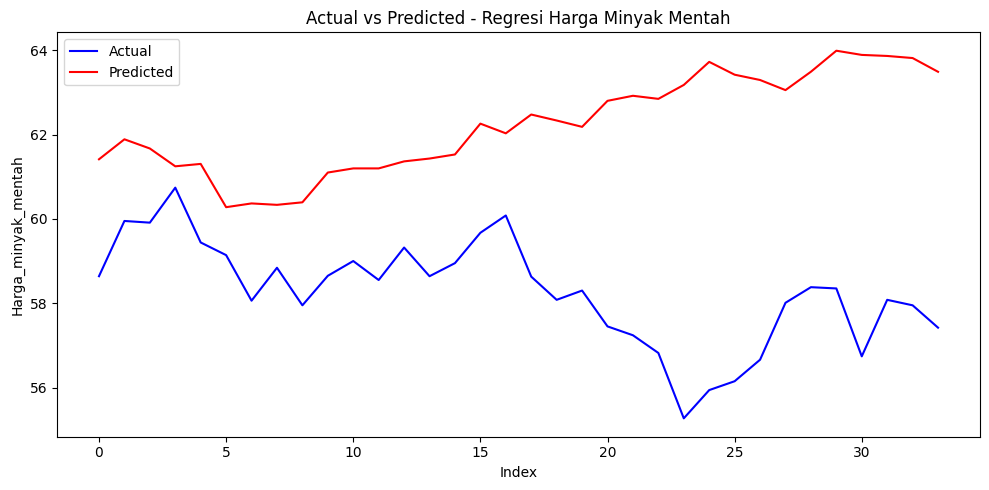

MAE   = 3.9622
MSE   = 20.1150
RMSE  = 4.4850
MAPE  = 0.0687


In [132]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Align index test_1 dan test_2 dulu
common_index_test = test.index.intersection(test.index)

x = x_test
y_true = y_test

# Prediksi pakai x dari test set, BUKAN predict() kosong
y_pred = model_lag_1.predict(x)

# Hitung metrik
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true))

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_true.values, color='blue', label='Actual')
plt.plot(y_pred.values, color='red', label='Predicted')



plt.title("Actual vs Predicted - Regresi Harga Minyak Mentah")
plt.xlabel("Index")
plt.ylabel("Harga_minyak_mentah")
plt.legend()
plt.tight_layout()
plt.show()

metrics_text = (
    f"MAE   = {mae:.4f}\n"
    f"MSE   = {mse:.4f}\n"
    f"RMSE  = {rmse:.4f}\n"
    f"MAPE  = {mape:.4f}"
)

print(metrics_text)

### Prediksi secara univariate untuk index harga dollar sebelum konflik

In [133]:
df_us_BK.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 131 entries, 2025-07-01 to 2025-12-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     131 non-null    float64
 1   Open      131 non-null    float64
 2   High      131 non-null    float64
 3   Low       131 non-null    float64
 4   Vol.      131 non-null    object 
 5   Change %  131 non-null    object 
dtypes: float64(4), object(2)
memory usage: 7.2+ KB


In [134]:
df_us_BK[:]

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2025-07-01,96.467,96.400,96.580,96.000,20.39K,-0.03%
2025-07-02,96.429,96.315,96.820,96.285,16.43K,-0.04%
2025-07-03,96.822,96.420,97.065,96.350,19.08K,0.41%
2025-07-04,96.822,96.660,96.760,96.515,9.10K,0.00%
2025-07-07,97.141,96.650,97.330,96.555,20.16K,0.33%
...,...,...,...,...,...,...
2025-12-24,97.681,97.550,97.695,97.425,7.55K,0.07%
2025-12-26,97.698,97.635,97.815,97.535,8.76K,0.02%
2025-12-29,97.732,97.790,97.875,97.605,8.17K,0.03%


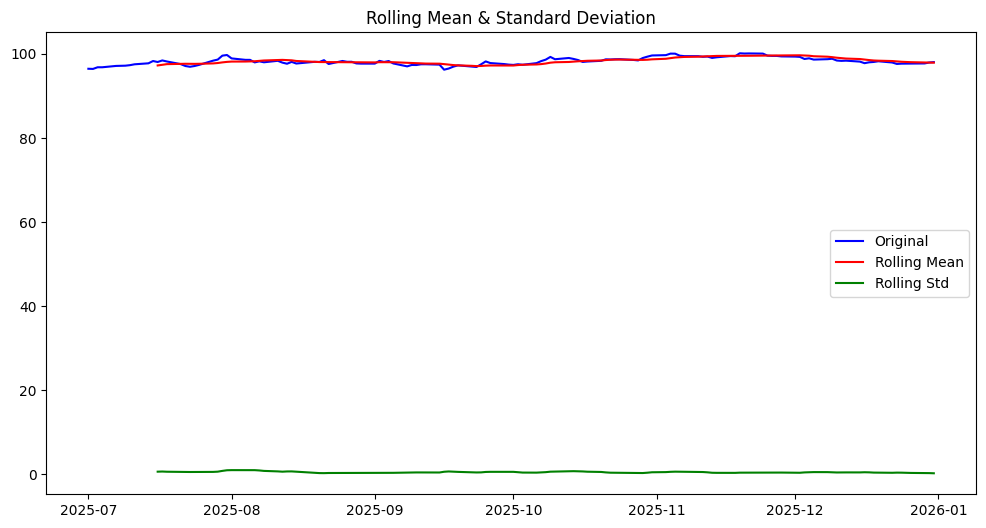

In [135]:
#Menghitung rolling statistics
roleman = df_us_BK['Price'].rolling(window=12).mean()
rolstd = df_us_BK['Price'].rolling(window=12).std()

#Plot rolling statistics:
orig = plt.plot(df_us_BK['Price'], color='blue',label='Original')
mean = plt.plot(roleman, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='green', label = 'Rolling Std')
plt.legend(loc = 'best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()


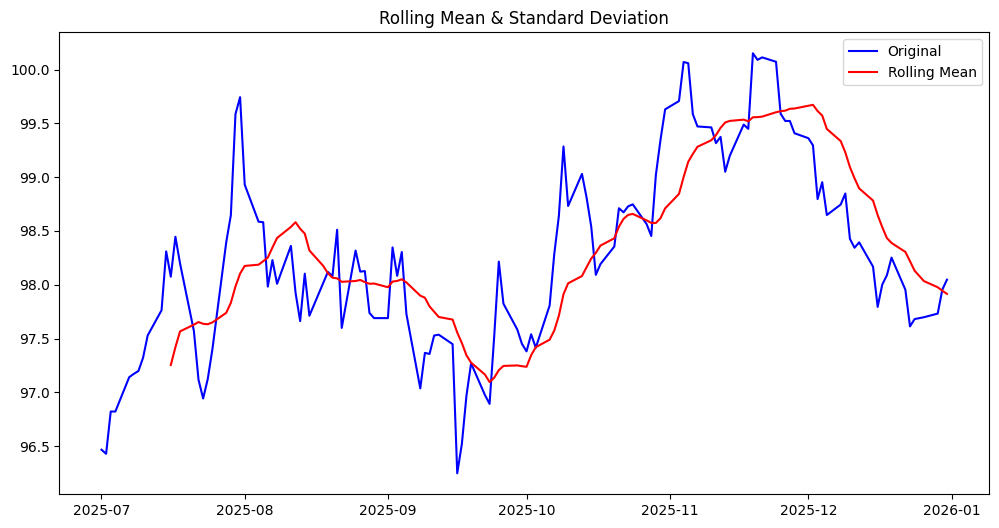

In [136]:
roleman = df_us_BK['Price'].rolling(window=12).mean()

orig = plt.plot(df_us_BK['Price'], color='blue',label='Original')
mean = plt.plot(roleman, color='red', label='Rolling Mean')
plt.legend(loc = 'best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()


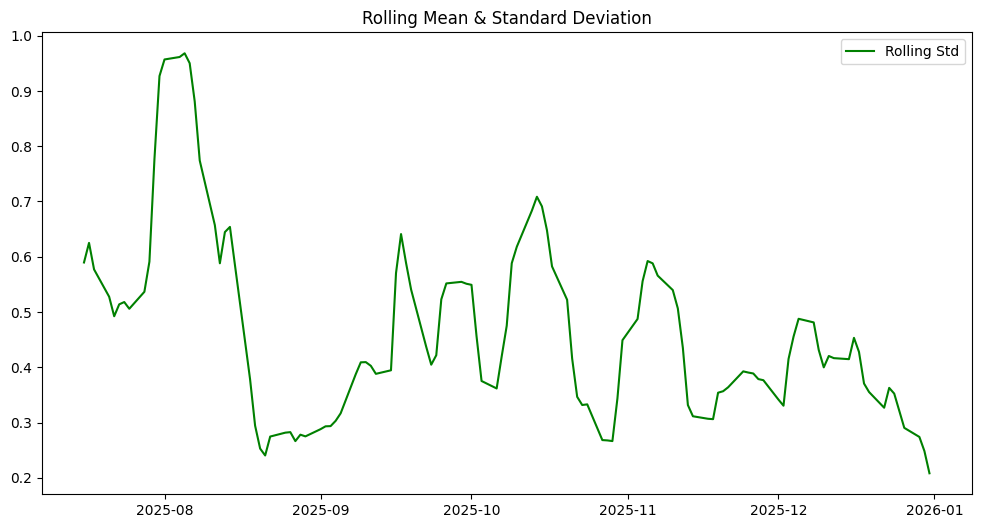

In [137]:
rolstd = df_us_BK['Price'].rolling(window=12).std()
std = plt.plot(rolstd, color='green', label = 'Rolling Std')

plt.legend(loc = 'best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

In [138]:
#Perform Dickey-Fuller test:
dftest_1 = adfuller(df_us_BK['Price'], autolag='AIC')
dfoutput_1 = pd.Series(dftest_1[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest_1[4].items():
        dfoutput_1['Critical Value (%s)'%key] = value
print(dfoutput_1)

Test Statistic                  -2.787340
p-value                          0.060105
#Lags Used                       0.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


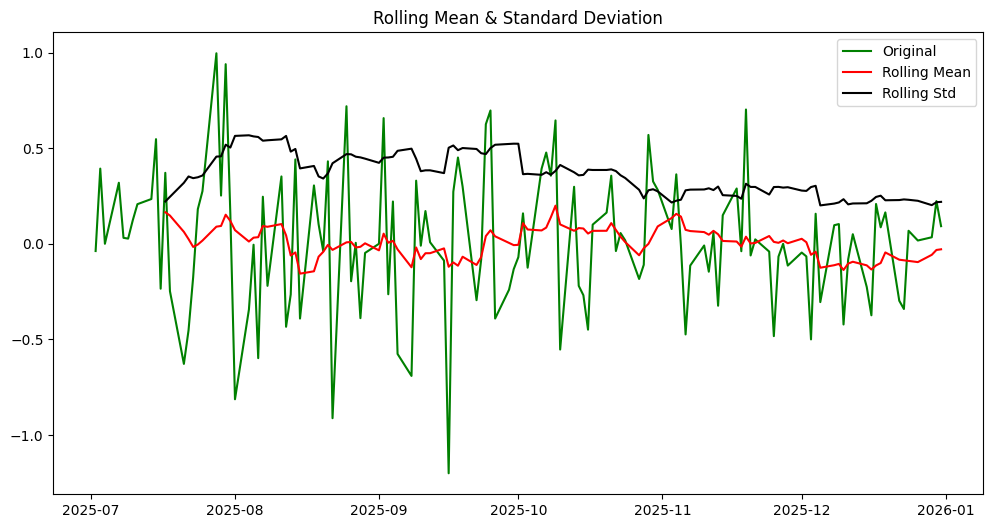

In [139]:
#Melakukan differencing pertama
df_us_diff_1 = df_us_BK['Price'] - df_us_BK['Price'].shift()
df_us_diff_1 = df_us_diff_1.dropna()

#Menghitung rolling statistics
rolmean = df_us_diff_1.rolling(window=12).mean()
rolstd = df_us_diff_1.rolling(window=12).std()


#Plot rolling statistics:
orig = plt.plot(df_us_diff_1, color = 'green', label = 'Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

In [140]:
#Perform Dickey-Fuller test:
dftest_2 = adfuller(df_us_diff_1, autolag='AIC')
dfoutput_2 = pd.Series(dftest_2[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest_2[4].items():
        dfoutput_2['Critical Value (%s)'%key] = value
print(dfoutput_2)

Test Statistic                -1.128601e+01
p-value                        1.417492e-20
#Lags Used                     0.000000e+00
Number of Observations Used    1.290000e+02
Critical Value (1%)           -3.482088e+00
Critical Value (5%)           -2.884219e+00
Critical Value (10%)          -2.578864e+00
dtype: float64


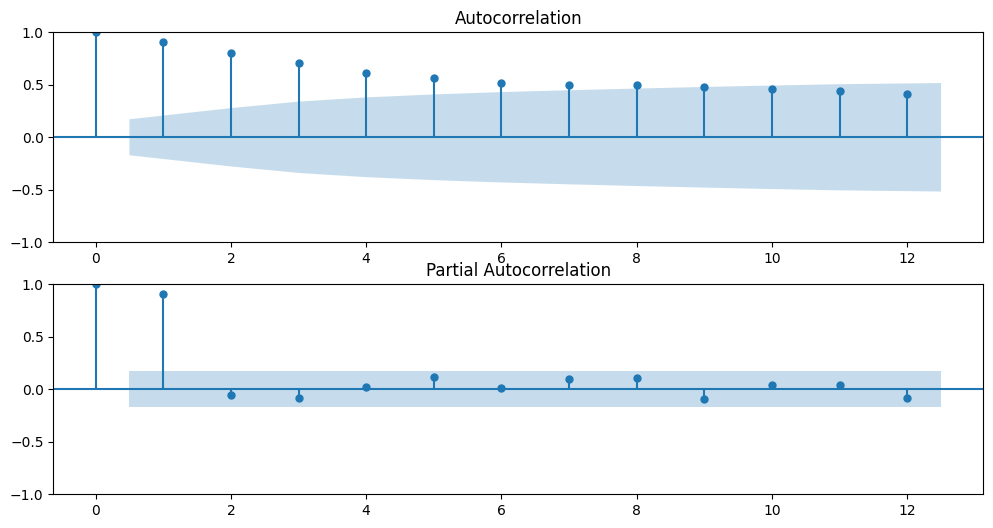

In [141]:
#Plot ACF dan PACF data asli
plot_acf_pacf(df_us_BK['Price'], lag=12
              )

lag musiman =  4


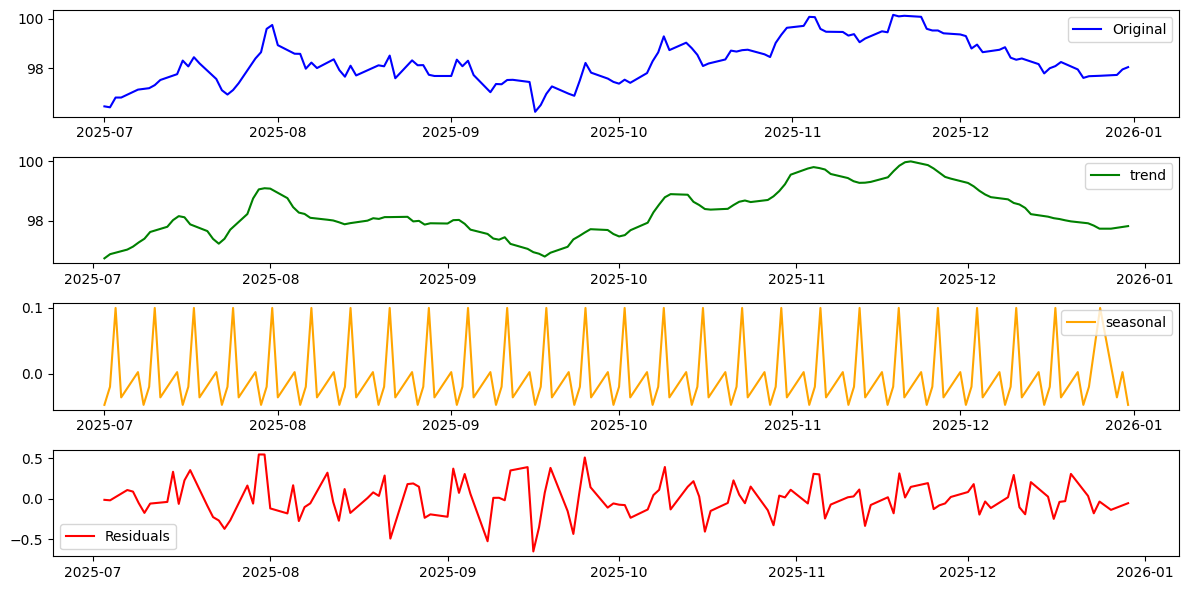

In [142]:
decompose(df_us_BK['Price'], "additive", period=5)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


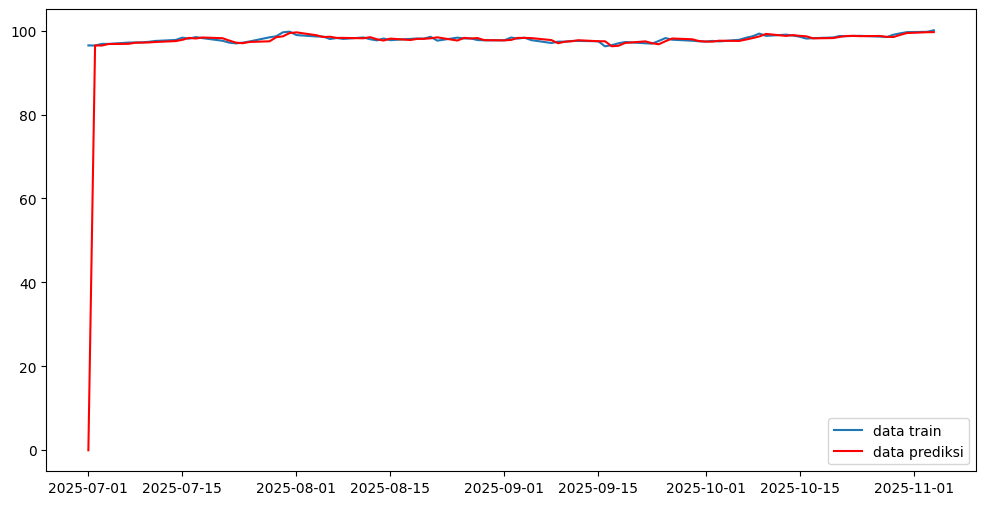

                                       SARIMAX Results                                        
Dep. Variable:                                  Price   No. Observations:                   91
Model:             SARIMAX(1, 1, 1)x(0, 0, [1, 2], 4)   Log Likelihood                 -43.531
Date:                                Sat, 18 Jul 2026   AIC                             97.063
Time:                                        13:42:18   BIC                            109.562
Sample:                                    07-01-2025   HQIC                           102.103
                                         - 11-04-2025                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8243      0.384     -2.145      0.032      -1.578      -0.071
ma.

In [143]:
#Bikin model SARIMA
train_size = int(len(df_us_BK)*0.7)
train_1 = df_us_BK['Price'][:train_size]                #menggunakan data sebelum differencing, karena komponen differencingnya sudah diwakili model
test_1 = df_us_BK['Price'][train_size:]
model_sarima = SARIMAX(train_1, order=(1,1,1), seasonal_order=(0,0,2,4))
results_SARIMA_us_BK = model_sarima.fit(disp=1)
predictions_SARIMA_diff = pd.Series(results_SARIMA_us_BK.fittedvalues,copy = True)


plt.plot(train_1, label='data train')
plt.plot(predictions_SARIMA_diff, color = 'red', label='data prediksi')
plt.legend(loc='best')
plt.show()
print(results_SARIMA_us_BK.summary())

mse =  1.9362894931975028
rmse =  1.3915061958890096
mae =  1.1586025317157194
mape =  0.011777812772882191


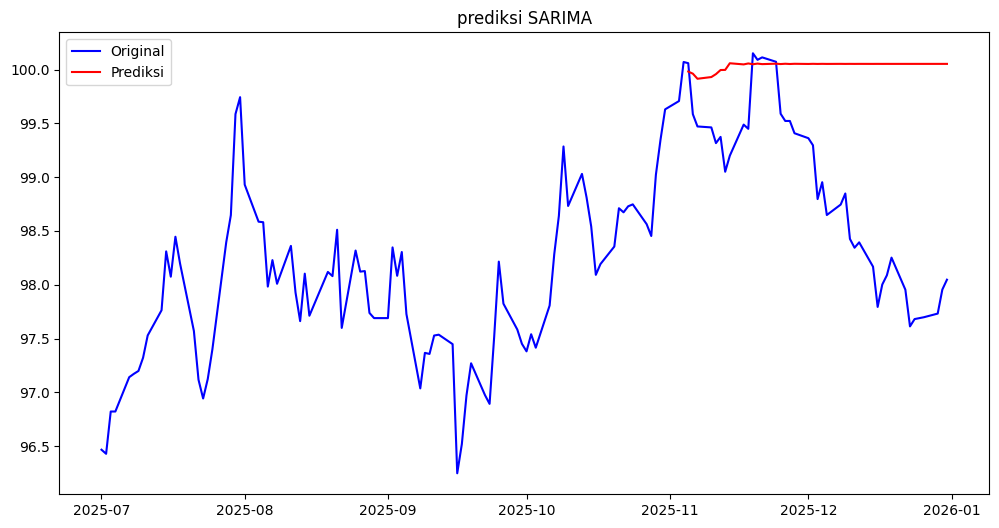

In [144]:
pred = results_SARIMA_us_BK.predict(start=len(train_1), end=len(df_us_BK['Price']) - 1)  #hitung prediksi dari indeks testingnya saja
pred.index = test_1.index  #menyamakan indeks
print('mse = ', mean_squared_error(test_1, pred))
print('rmse = ', root_mean_squared_error(test_1, pred))
print('mae = ', mean_absolute_error(test_1, pred))
print('mape = ', mean_absolute_percentage_error(test_1, pred))

orig = plt.plot(df_us_BK['Price'], color='blue',label='Original')
prediksi = plt.plot(pred, color='red',label='Prediksi')
plt.legend(loc='best')
plt.title('prediksi SARIMA')
plt.show()

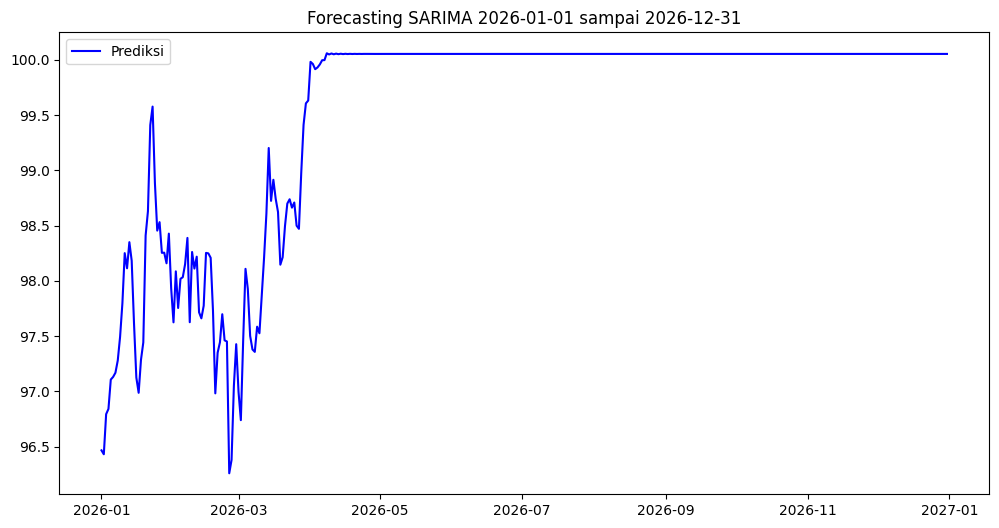

,predicted_mean
2026-01-01,96.466999
2026-01-02,96.431628
2026-01-03,96.794286
2026-01-04,96.841987
2026-01-05,97.107173
...,...
2026-12-27,100.052439
2026-12-28,100.052439
2026-12-29,100.052439
2026-12-30,100.052439


In [145]:
#@title
dari = '2026-01-01' #@param {type:"string"}
sampai = "2026-12-31" #@param {type:"string"}
data_terakhir = df_us_BK.index[-1]

# Convert 'dari' dan 'sampai' ke datetime
dari_dt = datetime.strptime(dari, '%Y-%m-%d')
sampai_dt = datetime.strptime(sampai, '%Y-%m-%d')

# selisih HARI dari data terakhir ke tanggal mulai forecast
awal = (dari_dt - data_terakhir).days

# selisih HARI dari tanggal mulai ke tanggal akhir forecast
akhir = (sampai_dt - dari_dt).days

forecasting_us_BK = results_SARIMA_us_BK.predict(start=awal, end=awal + akhir)
forecasting_us_BK.index = pd.date_range(start=dari_dt, periods=akhir+1, freq='D')

plt.plot(forecasting_us_BK, color='blue', label='Prediksi')
plt.legend(loc='best')
plt.title('Forecasting SARIMA '+dari+" sampai "+sampai)
plt.show()

forecasting_us_BK

In [146]:
forecasting_us_BK.shape

(365,)

In [147]:
forecasting_us_BK.to_csv('forecast_indexUS_2026.csv', index= True, encoding='utf-8-sig')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


mse = 0.054870318126119054
rmse = 0.2342441421383234
mae = 0.17189539568703083
mape = 0.001739179986058077


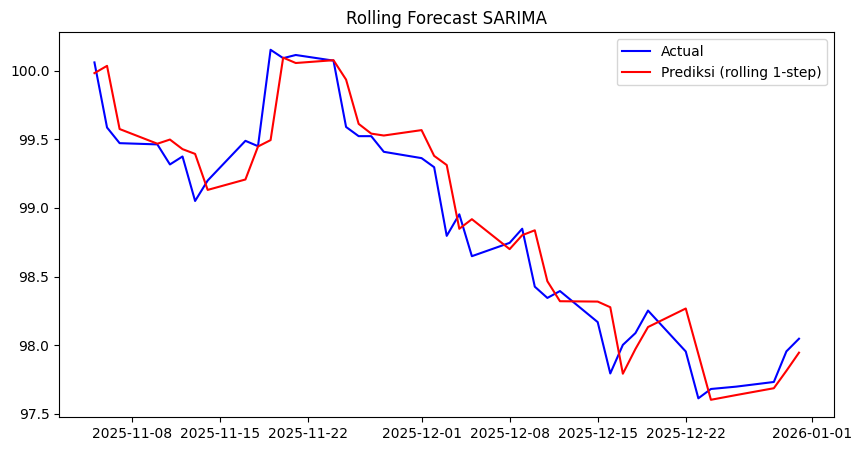

In [148]:
history = list(train_1)
predictions = []

for t in range(len(test_1)):
    model = SARIMAX(history, order=(1,1,1), seasonal_order=(0,0,2,4))
    fit = model.fit(disp=0)
    yhat = fit.forecast()[0]
    predictions.append(yhat)
    history.append(test_1.iloc[t])  # update dengan data aktual satu per satu

pred_rolling = pd.Series(predictions, index=test_1.index)


# Metrik
print('mse =', mean_squared_error(test_1, pred_rolling))
print('rmse =', root_mean_squared_error(test_1, pred_rolling))
print('mae =', mean_absolute_error(test_1, pred_rolling))
print('mape =', mean_absolute_percentage_error(test_1, pred_rolling))


plt.figure(figsize=(10,5))
plt.plot(test_1, color='blue', label='Actual')
plt.plot(pred_rolling, color='red', label='Prediksi (rolling 1-step)')
plt.legend(loc='best')
plt.title('Rolling Forecast SARIMA')
plt.show()

In [149]:
df_us_BK.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2025-07-01,96.467,96.400,96.580,96.000,20.39K,-0.03%
2025-07-02,96.429,96.315,96.820,96.285,16.43K,-0.04%
2025-07-03,96.822,96.420,97.065,96.350,19.08K,0.41%
2025-07-04,96.822,96.660,96.760,96.515,9.10K,0.00%
2025-07-07,97.141,96.650,97.330,96.555,20.16K,0.33%


In [150]:
model_final_2 = SARIMAX(df_us_BK['Price'], order=(1,1,1), seasonal_order=(0,0,2,4))
results_final_2 = model_final_2.fit(disp=1)
forecast_365 = results_final_2.get_forecast(steps=261)

pred_mean = forecast_365.predicted_mean          # nilai prediksi
conf_int = forecast_365.conf_int(alpha=0.05)      # interval kepercayaan 95%

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python

In [151]:
pred_mean

,predicted_mean
131,98.055833
132,98.002405
133,97.938139
134,97.931710
135,97.940523
...,...
387,97.979030
388,97.979030
389,97.979030
390,97.979030


In [152]:
pred_mean.to_csv('Rolling_forward_BK.csv', index= True, encoding='utf-8-sig')

### Prediksi untuk minyak mentah menggunakan model_1

In [153]:
x_baru_1 = pd.read_csv('forecast_indexUS_2026.csv', index_col=0)

# cek dulu strukturnya
print(x_baru_1.shape)   # harus (365, 1)
print(x_baru_1.columns) # cek nama kolomnya apa

(365, 1)
Index(['predicted_mean'], dtype='object')


In [154]:
import statsmodels.api as sm

  # ganti dengan nilai Index_US yang mau diprediksi

# WAJIB tambah constant juga di data baru, biar bentuknya cocok sama X waktu fit
X_baru_1 = sm.add_constant(x_baru_1, has_constant='add')

# Prediksi
prediksi_BK = model_lag_1.predict(X_baru_1)
print(prediksi_BK)

2026-01-01    65.662033
2026-01-02    65.713737
2026-01-03    65.183604
2026-01-04    65.113876
2026-01-05    64.726226
                ...    
2026-12-27    60.420840
2026-12-28    60.420840
2026-12-29    60.420840
2026-12-30    60.420840
2026-12-31    60.420840
Length: 365, dtype: float64


In [155]:
prediksi_BK.index = pd.to_datetime(prediksi_BK.index)

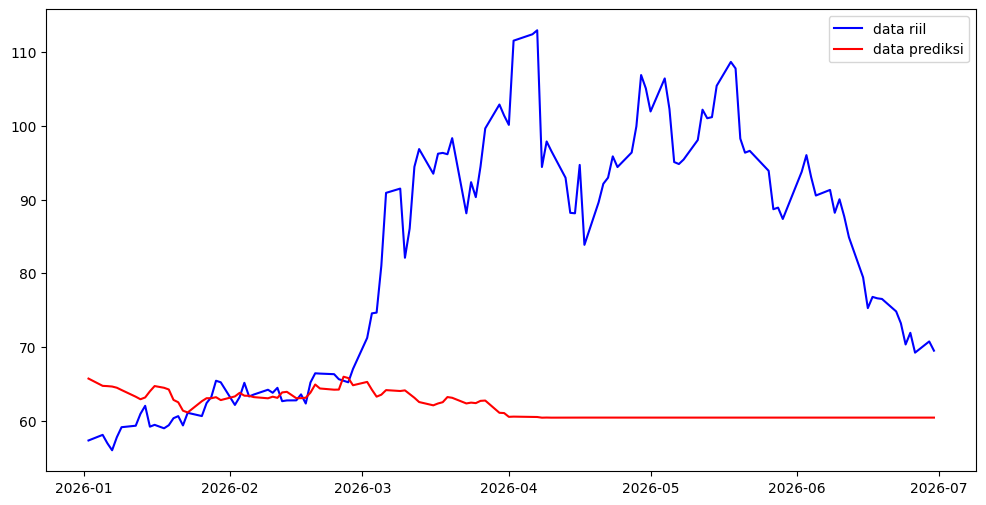

Jumlah tanggal yang match: 128


In [156]:
# ambil rentang tanggal yang MEMANG ada di kedua data
common_index_plot = df_minyak_AK.index.intersection(prediksi_BK.index)

plt.plot(df_minyak_AK.loc[common_index_plot, 'Terakhir'], label='data riil', color='blue')
plt.plot(prediksi_BK.loc[common_index_plot], label='data prediksi', color='red')
plt.legend(loc='best')
plt.show()

print(f"Jumlah tanggal yang match: {len(common_index_plot)}")

df_minyak_AK = df_minyak_AK.loc['2026-01-01':'2026-06-30']  # ini overwrite ke variabel sama

### Prediksi untuk minyak mentah menggunakan model_1

In [157]:
x_baru_2 = pd.read_csv('Rolling_forward_BK.csv', index_col=0)
print(x_baru_2.shape)
print(x_baru_2.columns) # cek nama kolomnya apa

(261, 1)
Index(['predicted_mean'], dtype='object')


In [158]:
import statsmodels.api as sm

  # ganti dengan nilai Index_US yang mau diprediksi

# WAJIB tambah constant juga di data baru, biar bentuknya cocok sama X waktu fit

X_baru_2 = sm.add_constant(x_baru_2, has_constant='add')
# Prediksi

prediksi_BK_2 = model_lag_1.predict(X_baru_2)
print(prediksi_BK)
print(prediksi_BK_2)

2026-01-01    65.662033
2026-01-02    65.713737
2026-01-03    65.183604
2026-01-04    65.113876
2026-01-05    64.726226
                ...    
2026-12-27    60.420840
2026-12-28    60.420840
2026-12-29    60.420840
2026-12-30    60.420840
2026-12-31    60.420840
Length: 365, dtype: float64
131    63.339476
132    63.417578
133    63.511521
134    63.520920
135    63.508037
         ...    
387    63.451746
388    63.451746
389    63.451746
390    63.451746
391    63.451746
Length: 261, dtype: float64


In [159]:
prediksi_BK.to_csv('prediksi_harga_minyak_mentah_sebelum konflik_S', index= True, encoding='utf-8-sig')
prediksi_BK_2.to_csv('prediksi_harga_minyak_mentah_sebelum konflik_R', index= True, encoding='utf-8-sig')

## Sesudah konflik

### Membuat Regresi Linear untuk Index Harga Dollar terhadap Harga minyak mentah


*   Menggunakan data df_us_AK terhadap df_minyak_AK



In [160]:
df_us_AK.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 128 entries, 2026-01-02 to 2026-06-30
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     128 non-null    float64
 1   Open      128 non-null    float64
 2   High      128 non-null    float64
 3   Low       128 non-null    float64
 4   Vol.      128 non-null    object 
 5   Change %  128 non-null    object 
dtypes: float64(4), object(2)
memory usage: 7.0+ KB


In [161]:
df_minyak_AK.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 128 entries, 2026-01-02 to 2026-06-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Terakhir    128 non-null    float64
 1   Pembukaan   128 non-null    object 
 2   Tertinggi   128 non-null    object 
 3   Terendah    128 non-null    object 
 4   Vol.        126 non-null    object 
 5   Perubahan%  128 non-null    object 
dtypes: float64(1), object(5)
memory usage: 7.0+ KB


In [162]:
# 1. (skip diff, langsung pakai level harga)

# 2. Align + shift (lag H-1)
common_index = df_us_AK.index.intersection(df_minyak_AK.index)
x_2 = df_us_AK.loc[common_index, 'Price'].shift(1)
y_2 = df_minyak_AK.loc[common_index, 'Terakhir']

# 3. Gabung — pakai x_2, y_2
df_gabung_2 = pd.concat([x_2, y_2], axis=1).dropna()
df_gabung_2.columns = ['Price_lag1', 'Terakhir']
print(df_gabung_2.shape)  # cek dulu, harus (n, 2)

# 4. Split
train_size = int(len(df_gabung_2) * 0.69)
train_3 = df_gabung_2.iloc[:train_size]
test_4 = df_gabung_2.iloc[train_size:]

x_train_2 = sm.add_constant(train_3['Price_lag1'])
y_train_2 = train_3['Terakhir']
x_test_3 = sm.add_constant(test_4['Price_lag1'], has_constant='add')
y_test_3 = test_4['Terakhir']

# 5. Fit
model_lag_2 = sm.OLS(y_train_2, x_train_2).fit()
print(model_lag_2.summary())   # pakai model_lag_2

(125, 2)
                            OLS Regression Results                            
Dep. Variable:               Terakhir   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     43.25
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           3.87e-09
Time:                        13:42:48   Log-Likelihood:                -350.24
No. Observations:                  86   AIC:                             704.5
Df Residuals:                      84   BIC:                             709.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -925.4180    152.830     -6.055

In [163]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_lag_2.resid, model_lag_2.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(2.7359651175898976), 'LM p-value': np.float64(0.09811221279721088), 'F-Statistic': np.float64(2.760148126404357), 'F p-value': np.float64(0.10036734596944456)}


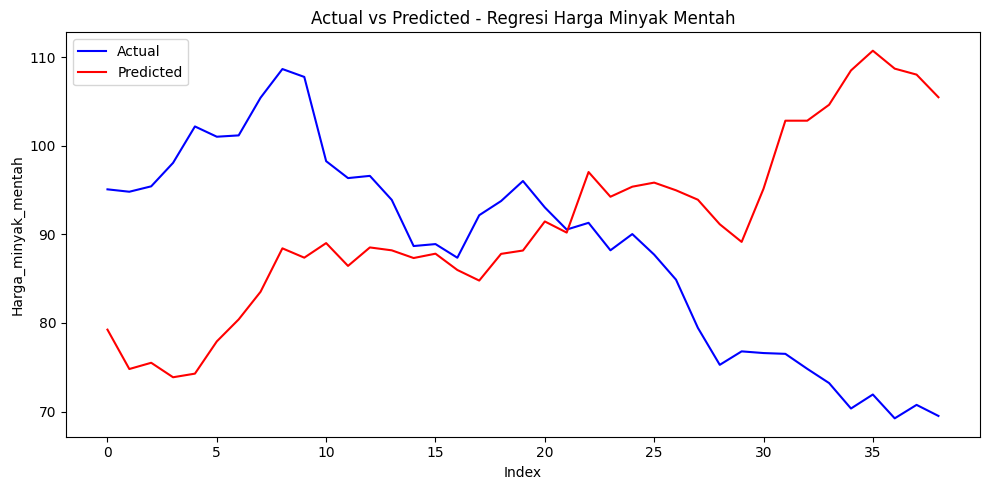

MAE   = 16.5691
MSE   = 410.6853
RMSE  = 20.2654
MAPE  = 0.1999


In [164]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# x_test_3 dan y_test_3 SUDAH align dari proses split sebelumnya, jadi langsung pakai
x_4 = x_test_3
y_true_4 = y_test_3

# Prediksi pakai x_4, bukan x
y_pred_4 = model_lag_2.predict(x_4)

# Hitung metrik
mae  = mean_absolute_error(y_true_4, y_pred_4)
mse  = mean_squared_error(y_true_4, y_pred_4)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true_4 - y_pred_4) / y_true_4))

# Plot — pakai y_true_4 dan y_pred_4
plt.figure(figsize=(10,5))
plt.plot(y_true_4.values, color='blue', label='Actual')
plt.plot(y_pred_4.values, color='red', label='Predicted')

plt.title("Actual vs Predicted - Regresi Harga Minyak Mentah")
plt.xlabel("Index")
plt.ylabel("Harga_minyak_mentah")
plt.legend()
plt.tight_layout()
plt.show()

metrics_text = (
    f"MAE   = {mae:.4f}\n"
    f"MSE   = {mse:.4f}\n"
    f"RMSE  = {rmse:.4f}\n"
    f"MAPE  = {mape:.4f}"
)
print(metrics_text)

### Prediksi secara univariate untuk index harga dollar sesudah konflik

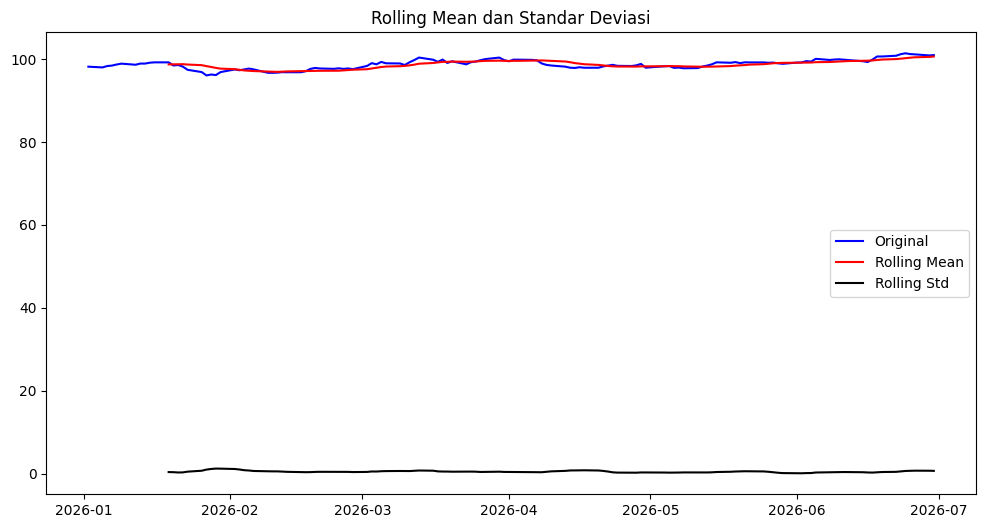

In [165]:
#Menghitung rolling statistics
rolmean = df_us_AK['Price'].rolling(window=12).mean()
rolstd = df_us_AK['Price'].rolling(window=12).std()
#Plot rolling statistics:
orig = plt.plot(df_us_AK['Price'], color='blue',label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean dan Standar Deviasi')
plt.show()

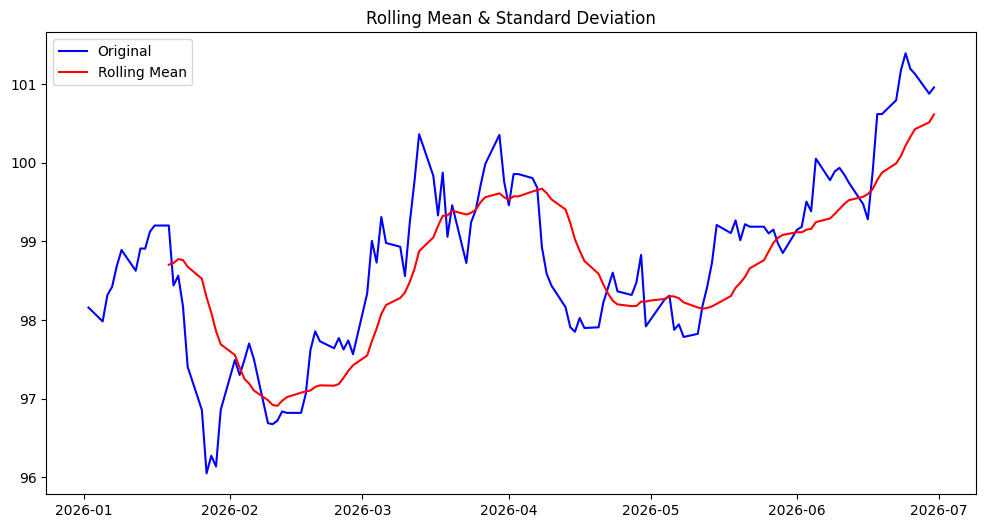

In [166]:
roleman = df_us_AK['Price'].rolling(window=12).mean()
orig = plt.plot(df_us_AK['Price'], color='blue',label='Original')
mean = plt.plot(roleman, color='red', label='Rolling Mean')

plt.legend(loc = 'best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

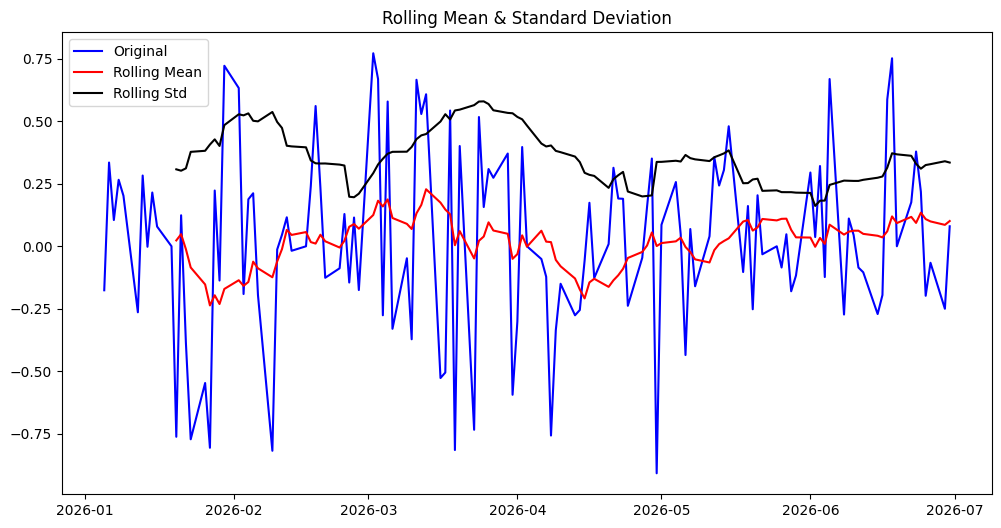

In [167]:
data_diff_1 = df_us_AK['Price'] - df_us_AK['Price'].shift()
data_diff_1 = data_diff_1.dropna()

#Menghitung rolling statistics
rolmean = data_diff_1.rolling(window=12).mean()
rolstd = data_diff_1.rolling(window=12).std()

#Plot rolling statistics:
orig = plt.plot(data_diff_1, color='blue', label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

In [168]:
dftest1 = adfuller(data_diff_1, autolag='AIC')
dfoutput = pd.Series(dftest1[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest1[4].items():
        dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Test Statistic                -1.083782e+01
p-value                        1.644831e-19
#Lags Used                     0.000000e+00
Number of Observations Used    1.260000e+02
Critical Value (1%)           -3.483346e+00
Critical Value (5%)           -2.884766e+00
Critical Value (10%)          -2.579156e+00
dtype: float64


/tmp/ipykernel_806/4016953731.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test = df_us_AK['Price'][train_size]


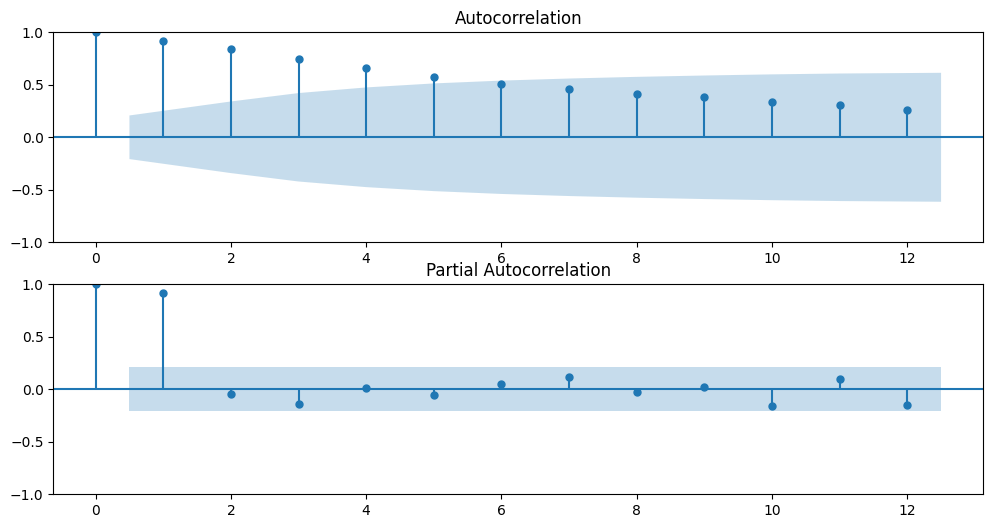

In [169]:
# split data
train_size = int(len(df_us_AK['Price']) * 0.7) # Menentukan banyaknya data train yaitu sebesar 70% data
train = df_us_AK['Price'][:train_size]
test = df_us_AK['Price'][train_size]

#Plot ACF dan PACF
plt.figure()
plt.subplot(211)
plot_acf(df_us_AK['Price'][:train_size], ax=plt.gca(), lags=12)
plt.subplot(212)
plot_pacf(df_us_AK['Price'][:train_size], ax=plt.gca(), lags=12)
plt.show()

lag musiman =  4


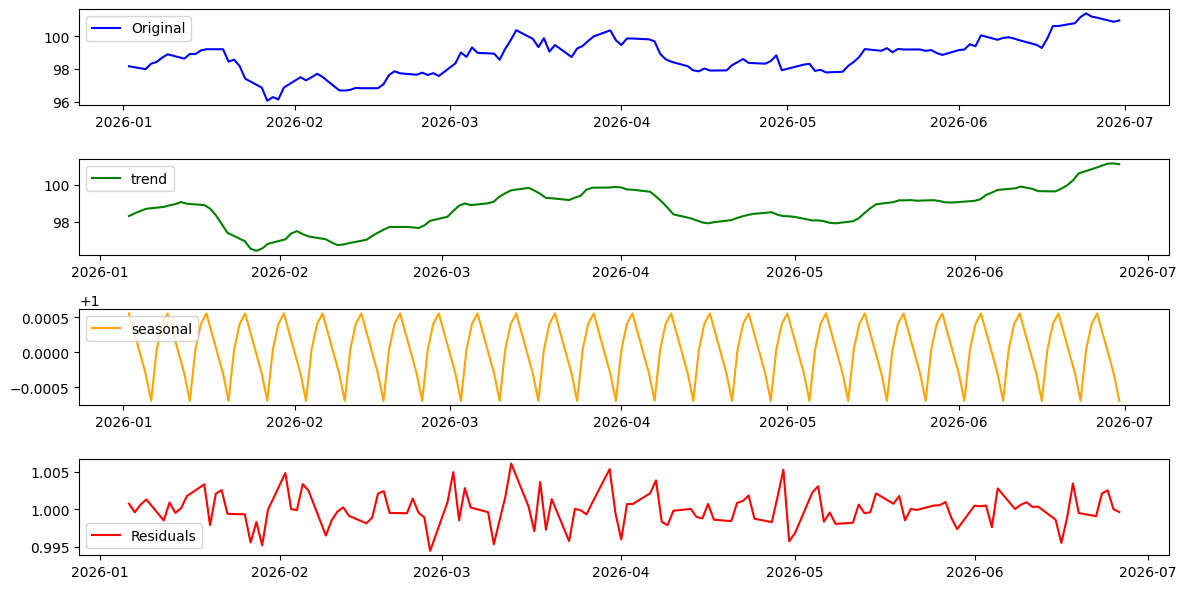

In [170]:
decompose(df_us_AK['Price'], "multiplicative")

In [171]:
df_diff_4 = df_us_AK['Price'].diff(4).dropna()
uji_stasioner(df_diff_4)

Test Statistic                  -2.274706
p-value                          0.180256
#Lags Used                      12.000000
Number of Observations Used    111.000000
Critical Value (1%)             -3.490683
Critical Value (5%)             -2.887952
Critical Value (10%)            -2.580857
dtype: float64


In [172]:
data_diff_1_4 = data_diff_1.diff(4).dropna()
uji_stasioner(data_diff_1_4)

Test Statistic                -6.528437e+00
p-value                        1.000931e-08
#Lags Used                     1.100000e+01
Number of Observations Used    1.110000e+02
Critical Value (1%)           -3.490683e+00
Critical Value (5%)           -2.887952e+00
Critical Value (10%)          -2.580857e+00
dtype: float64


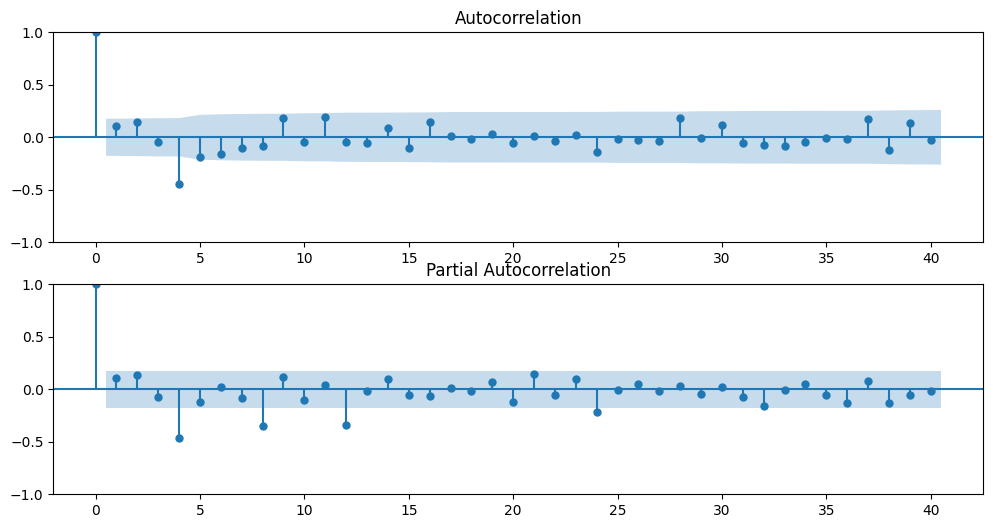

In [173]:
plot_acf_pacf(data_diff_1_4, lag=40)

lag musiman =  4


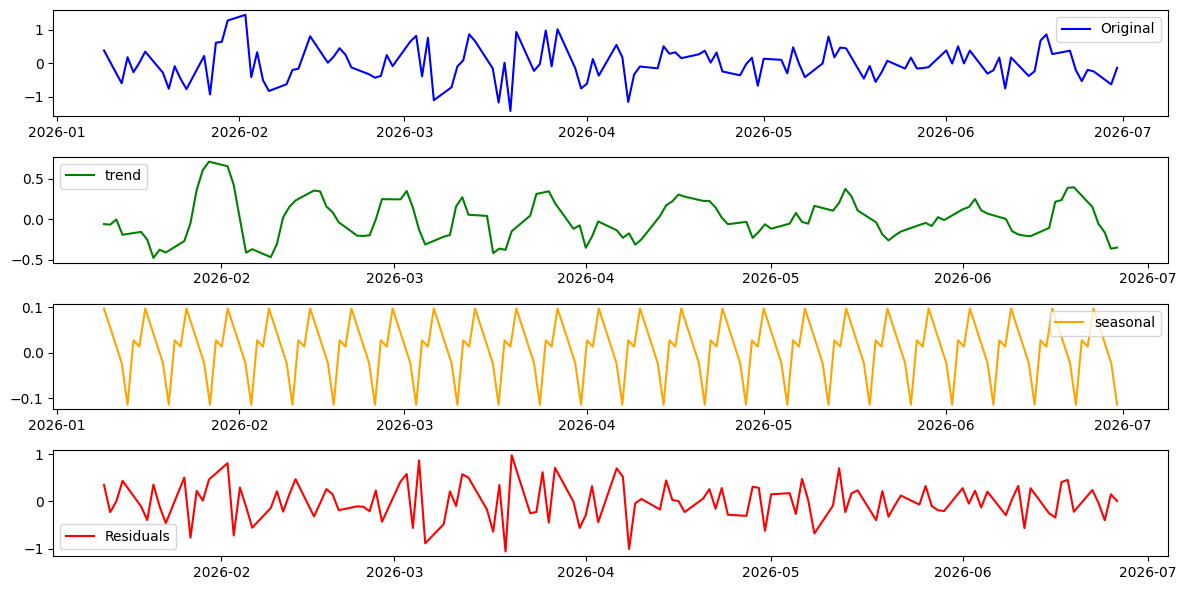

In [174]:
decompose(data_diff_1_4, "additive")

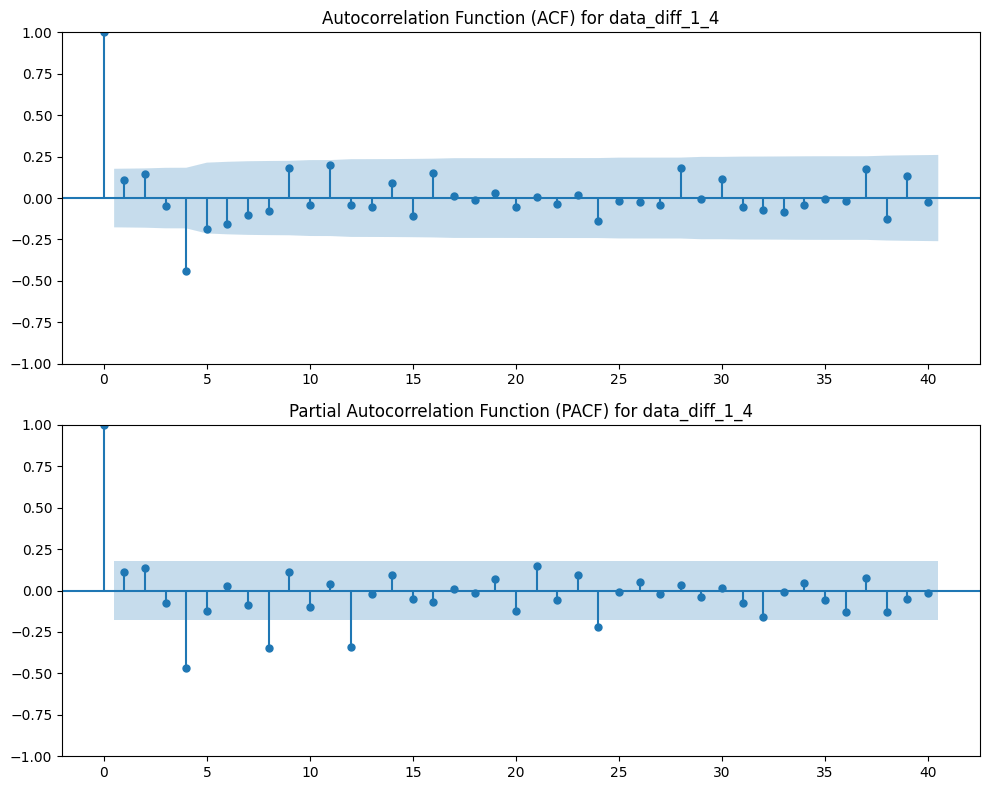

In [175]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Plot ACF dan PACF data asli
plt.figure(figsize=(10, 8))
plt.subplot(211)
plot_acf(data_diff_1_4, ax=plt.gca(), lags=40)
plt.title('Autocorrelation Function (ACF) for data_diff_1_4')

plt.subplot(212)
plot_pacf(data_diff_1_4, ax=plt.gca(), lags=40)
plt.title('Partial Autocorrelation Function (PACF) for data_diff_1_4')

plt.tight_layout()
plt.show()

In [176]:
df_us_AK['Price'][:train_size]

,Price
Date,
2026-01-02,98.158
2026-01-05,97.982
2026-01-06,98.317
2026-01-07,98.422
2026-01-08,98.688
...,...
2026-04-30,97.919
2026-05-01,98.005
2026-05-04,98.262


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


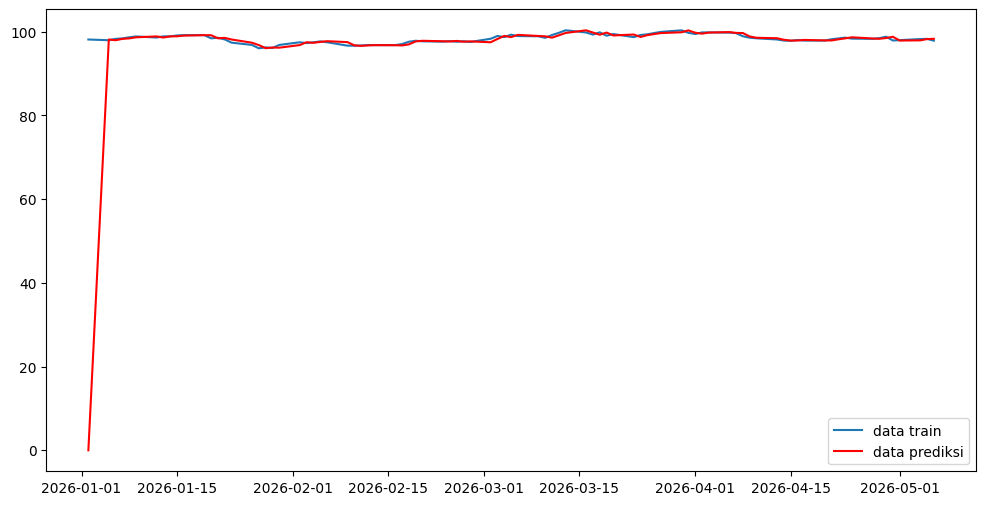

                                     SARIMAX Results                                     
Dep. Variable:                             Price   No. Observations:                   89
Model:             SARIMAX(1, 1, 1)x(3, 0, 1, 4)   Log Likelihood                 -42.413
Date:                           Sat, 18 Jul 2026   AIC                             98.825
Time:                                   13:42:52   BIC                            116.166
Sample:                               01-02-2026   HQIC                           105.811
                                    - 05-06-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6664      3.019     -0.221      0.825      -6.584       5.251
ma.L1          0.6498      3.071      0.212

In [177]:
#Bikin model SARIMA
train_size = int(len(df_us_AK)*0.7)
train = df_us_AK['Price'][:train_size]                #menggunakan data sebelum differencing, karena komponen differencingnya sudah diwakili model
test = df_us_AK['Price'][train_size:]
model_sarima_1 = SARIMAX(train, order=(1,1,1), seasonal_order=(3,0,1,4))
results_SARIMA_us_AK = model_sarima_1.fit(disp=1)
predictions_SARIMA_diff = pd.Series(results_SARIMA_us_AK.fittedvalues,copy = True)


plt.plot(train, label='data train')
plt.plot(predictions_SARIMA_diff, color = 'red', label='data prediksi')
plt.legend(loc='best')
plt.show()
print(results_SARIMA_us_AK.summary())

mse =  3.595343516638249
rmse =  1.8961391079343966
mae =  1.6558194380693174
mape =  0.016544610410436606


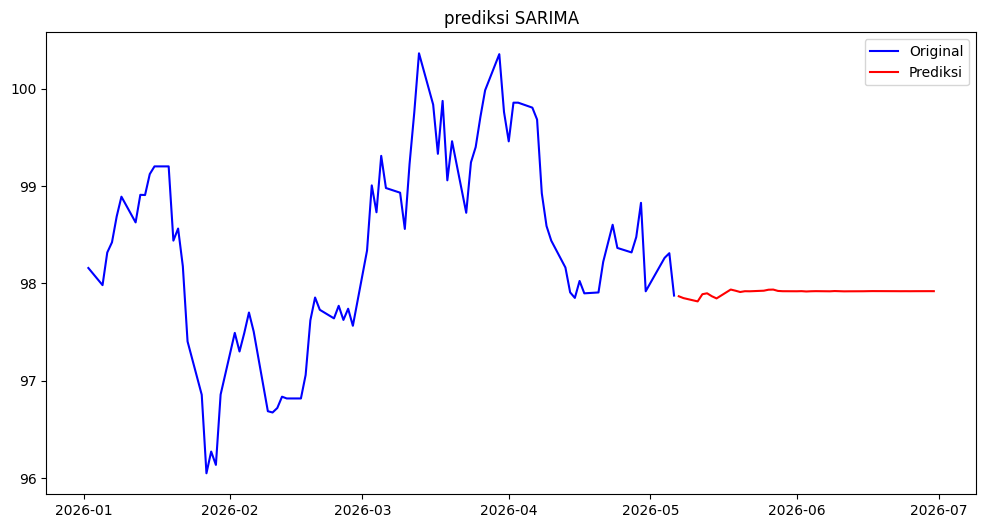

In [178]:
pred = results_SARIMA_us_AK.predict(start=len(train), end=len(df_us_AK) - 1)  #hitung prediksi dari indeks testingnya saja
pred.index = test.index  #menyamakan indeks

print('mse = ', mean_squared_error(test, pred))
print('rmse = ', root_mean_squared_error(test, pred))
print('mae = ', mean_absolute_error(test, pred))
print('mape = ', mean_absolute_percentage_error(test, pred))

orig = plt.plot(train, color='blue',label='Original')
prediksi = plt.plot(pred, color='red',label='Prediksi')
plt.legend(loc='best')
plt.title('prediksi SARIMA')
plt.show()

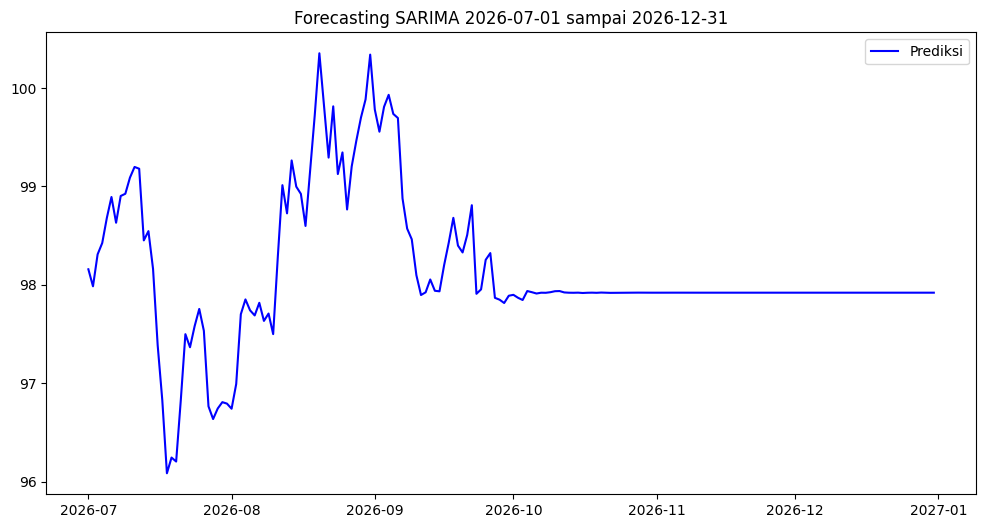

,predicted_mean
2026-07-01,98.158000
2026-07-02,97.984971
2026-07-03,98.309488
2026-07-04,98.425100
2026-07-05,98.680533
...,...
2026-12-27,97.920074
2026-12-28,97.920074
2026-12-29,97.920075
2026-12-30,97.920075


In [179]:
#@title
dari = '2026-07-01' #@param {type:"string"}
sampai = "2026-12-31" #@param {type:"string"}
data_terakhir = df_us_AK.index[-1]

# Convert 'dari' dan 'sampai' ke datetime
dari_dt = datetime.strptime(dari, '%Y-%m-%d')
sampai_dt = datetime.strptime(sampai, '%Y-%m-%d')

# selisih HARI dari data terakhir ke tanggal mulai forecast
awal = (dari_dt - data_terakhir).days

# selisih HARI dari tanggal mulai ke tanggal akhir forecast
akhir = (sampai_dt - dari_dt).days

forecasting_us_AK = results_SARIMA_us_AK.predict(start=awal, end=awal + akhir)
forecasting_us_AK.index = pd.date_range(start=dari_dt, periods=akhir+1, freq='D')

plt.plot(forecasting_us_AK, color='blue', label='Prediksi')
plt.legend(loc='best')
plt.title('Forecasting SARIMA '+dari+" sampai "+sampai)
plt.show()

forecasting_us_AK

In [180]:
forecasting_us_AK.to_csv('forecast_indexUS_2027_AK.csv', index= True, encoding='utf-8-sig')

mse = 0.07616475967147182
rmse = 0.27597963633476985
mae = 0.21357164477471166
mape = 0.0021422441972165176


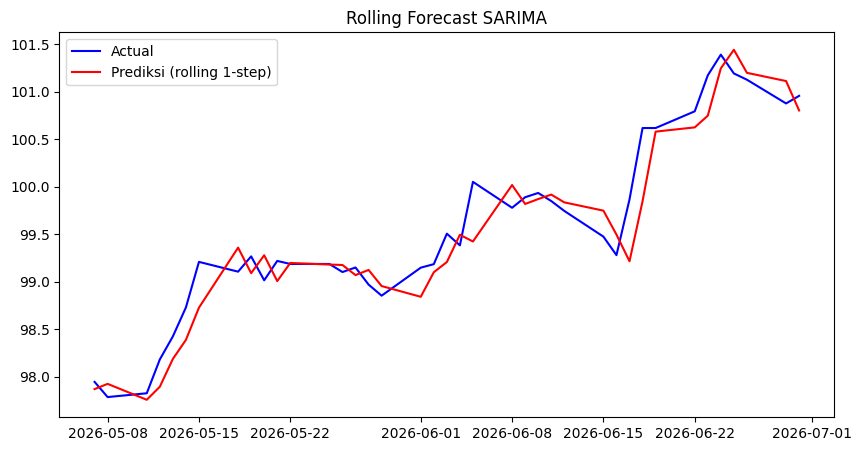

In [181]:
history = list(train)
predictions = []

for t in range(len(test)):
    model = SARIMAX(history, order=(1,1,1), seasonal_order=(3,0,1,4))
    fit = model.fit(disp=0)
    yhat = fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])  # update dengan data aktual satu per satu

pred_rolling = pd.Series(predictions, index=test.index)


# Metrik
print('mse =', mean_squared_error(test, pred_rolling))
print('rmse =', root_mean_squared_error(test, pred_rolling))
print('mae =', mean_absolute_error(test, pred_rolling))
print('mape =', mean_absolute_percentage_error(test, pred_rolling))


plt.figure(figsize=(10,5))
plt.plot(test, color='blue', label='Actual')
plt.plot(pred_rolling, color='red', label='Prediksi (rolling 1-step)')
plt.legend(loc='best')
plt.title('Rolling Forecast SARIMA')
plt.show()

In [182]:
model_final = SARIMAX(df_us_AK['Price'], order=(1,1,1), seasonal_order=(3,0,1,4))
results_final = model_final.fit(disp=1)
forecast_365 = results_final.get_forecast(steps=184)

pred_mean = forecast_365.predicted_mean          # nilai prediksi
conf_int = forecast_365.conf_int(alpha=0.05)      # interval kepercayaan 95%

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


In [183]:
pred_mean

,predicted_mean
2026-07-01,100.968025
2026-07-02,100.968864
2026-07-03,100.888953
2026-07-06,100.830507
2026-07-07,100.838588
...,...
2027-03-09,100.876156
2027-03-10,100.876156
2027-03-11,100.876156
2027-03-12,100.876156


In [184]:
pred_mean.to_csv('Rolling_forward_AK.csv', index= True, encoding='utf-8-sig')

### Prediksi untuk minyak mentah menggunakan model_1

In [185]:
x_baru_3 = pd.read_csv('forecast_indexUS_2027_AK.csv', index_col=0)
x_baru_4 = pd.read_csv('Rolling_forward_AK.csv', index_col=0)
# cek dulu strukturnya
print(x_baru_3.shape)
print(x_baru_3.columns) # cek nama kolomnya apa
print(x_baru_4.shape)
print(x_baru_4.columns) # cek nama kolomnya apa

(184, 1)
Index(['predicted_mean'], dtype='object')
(184, 1)
Index(['predicted_mean'], dtype='object')


In [186]:
import statsmodels.api as sm

  # ganti dengan nilai Index_US yang mau diprediksi

# WAJIB tambah constant juga di data baru, biar bentuknya cocok sama X waktu fit
X_baru_3 = sm.add_constant(x_baru_3, has_constant='add')
X_baru_4 = sm.add_constant(x_baru_4, has_constant='add')
# Prediksi
prediksi_AK = model_lag_2.predict(X_baru_3)
prediksi_AK_2 = model_lag_2.predict(X_baru_4)
print(prediksi_AK)
print(prediksi_AK_2)

2026-07-01    77.689587
2026-07-02    75.921352
2026-07-03    79.237690
2026-07-04    80.419164
2026-07-05    83.029522
                ...    
2026-12-27    75.258146
2026-12-28    75.258152
2026-12-29    75.258157
2026-12-30    75.258155
2026-12-31    75.258156
Length: 184, dtype: float64
2026-07-01    106.406125
2026-07-02    106.414698
2026-07-03    105.598060
2026-07-06    105.000778
2026-07-07    105.083360
                 ...    
2027-03-09    105.467278
2027-03-10    105.467278
2027-03-11    105.467278
2027-03-12    105.467278
2027-03-15    105.467278
Length: 184, dtype: float64


In [187]:
prediksi_AK.to_csv('prediksi_harga_minyak_mentah_setelah konflik_S', index= True, encoding='utf-8-sig')
prediksi_AK_2.to_csv('prediksi_harga_minyak_mentah_setelah konflik_R', index= True, encoding='utf-8-sig')

In [188]:
prediksi_AK.index = pd.to_datetime(prediksi_AK.index)
prediksi_AK_2.index = pd.to_datetime(prediksi_AK_2.index)

In [189]:
df_minyak_AK.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 128 entries, 2026-01-02 to 2026-06-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Terakhir    128 non-null    float64
 1   Pembukaan   128 non-null    object 
 2   Tertinggi   128 non-null    object 
 3   Terendah    128 non-null    object 
 4   Vol.        126 non-null    object 
 5   Perubahan%  128 non-null    object 
dtypes: float64(1), object(5)
memory usage: 11.1+ KB


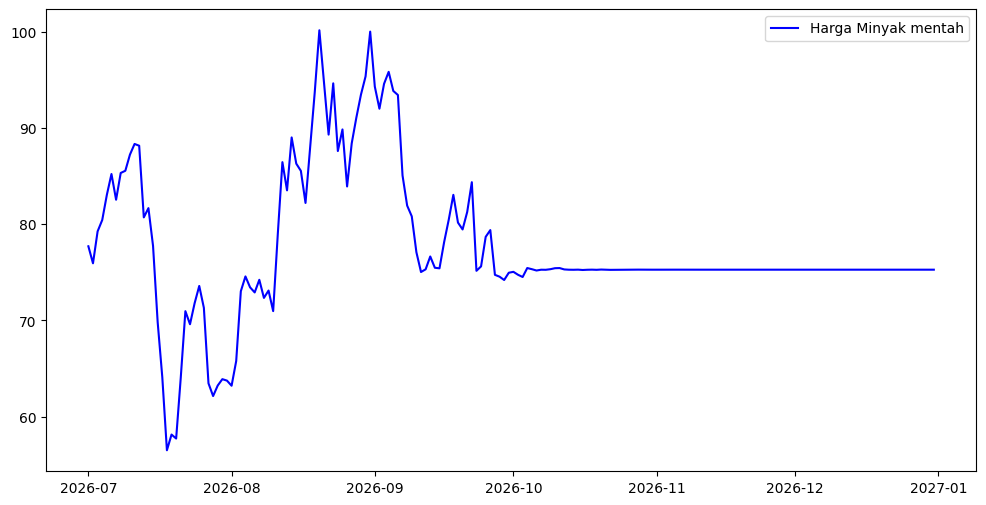

In [190]:

plt.plot(prediksi_AK, label='Harga Minyak mentah', color='blue')

plt.legend(loc='best')
plt.show()

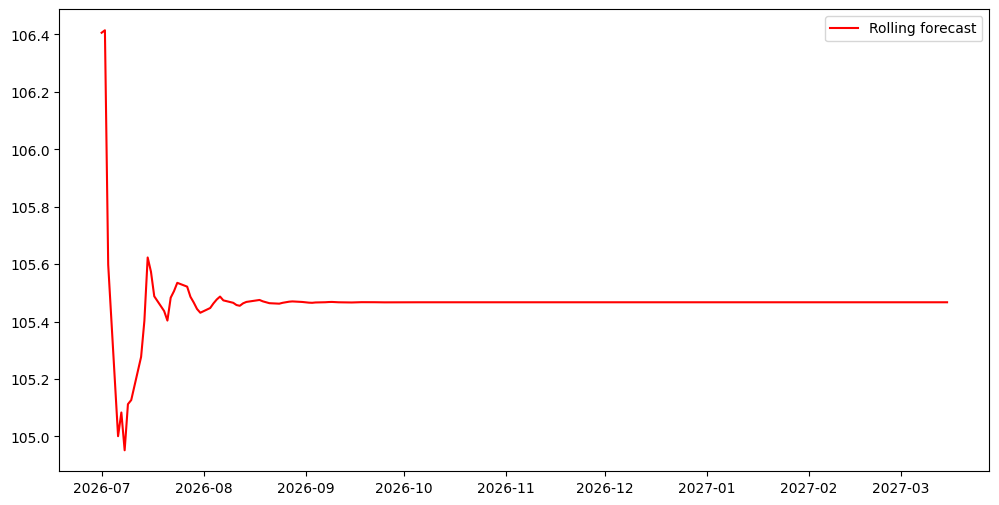

In [191]:
plt.plot(prediksi_AK_2, label='Rolling forecast', color='red')
plt.legend(loc='best')
plt.show()

## Interpretasi

In [192]:
df_1 = pd.read_csv('/content/prediksi_harga_minyak_mentah_setelah konflik_S')
df_2 = pd.read_csv('/content/prediksi_harga_minyak_mentah_sebelum konflik_S')
df_3 = pd.read_csv('/content/forecast_indexUS_2026.csv')
df_4 = pd.read_csv('/content/forecast_indexUS_2027_AK.csv')

In [193]:
df_3

,Unnamed: 0,predicted_mean
0,2026-01-01,96.466999
1,2026-01-02,96.431628
2,2026-01-03,96.794286
3,2026-01-04,96.841987
4,2026-01-05,97.107173
...,...,...
360,2026-12-27,100.052439
361,2026-12-28,100.052439
362,2026-12-29,100.052439
363,2026-12-30,100.052439


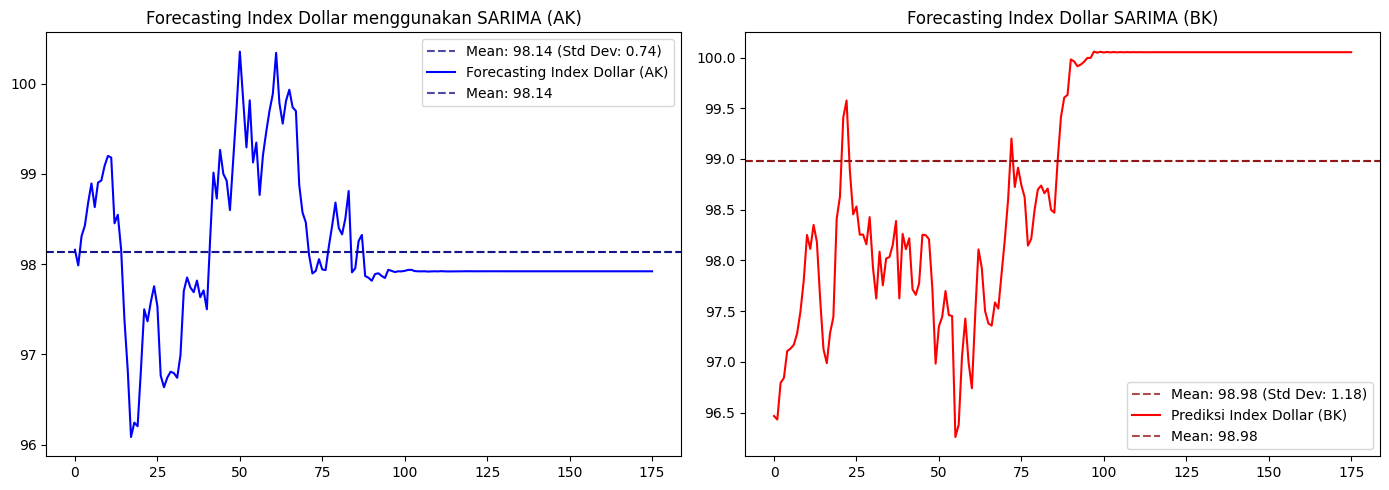

In [194]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik 1: Index Dollar (AK) ---
# 1. Ambil data yang di-plot agar perhitungan rata-ratanya akurat
data_ak = df_4['predicted_mean'].loc[:175]
mean_ak = data_ak.mean()  # Hitung rata-rata
std_ak = data_ak.std()
axes[0].axhline(mean_ak, color='navy', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_ak:.2f} (Std Dev: {std_ak:.2f})')
axes[0].plot(data_ak, color='blue', label='Forecasting Index Dollar (AK)')
# Tambahkan garis rata-rata (gunakan linestyle='--' untuk garis putus-putus)
axes[0].axhline(mean_ak, color='navy', linestyle='--', alpha=0.7, label=f'Mean: {mean_ak:.2f}')
axes[0].set_title('Forecasting Index Dollar menggunakan SARIMA (AK)')
axes[0].legend(loc='best')


# --- Grafik 2: SARIMA (BK) ---
# 2. Ambil data yang di-plot
data_bk = df_3['predicted_mean'].loc[:175]
mean_bk = data_bk.mean()  # Hitung rata-rata
std_bk = data_bk.std()
axes[1].axhline(mean_bk, color='darkred', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_bk:.2f} (Std Dev: {std_bk:.2f})')
axes[1].plot(data_bk, color='red', label='Prediksi Index Dollar (BK)')
# Tambahkan garis rata-rata
axes[1].axhline(mean_bk, color='darkred', linestyle='--', alpha=0.7, label=f'Mean: {mean_bk:.2f}')
axes[1].set_title('Forecasting Index Dollar SARIMA (BK)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

In [195]:
print(df_3['predicted_mean'].loc[:175].describe())
print(df_4['predicted_mean'].loc[:175].describe())

count    176.000000
mean      98.975993
std        1.176780
min       96.259684
25%       98.029451
50%       99.590661
75%      100.052439
max      100.058281
Name: predicted_mean, dtype: float64
count    176.000000
mean      98.138743
std        0.738814
min       96.084342
25%       97.919622
50%       97.920080
75%       98.405540
max      100.353709
Name: predicted_mean, dtype: float64


In [196]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  184 non-null    object 
 1   0           184 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.0+ KB


In [197]:
df_1

,Unnamed: 0,0
0,2026-07-01,77.689587
1,2026-07-02,75.921352
2,2026-07-03,79.237690
3,2026-07-04,80.419164
4,2026-07-05,83.029522
...,...,...
179,2026-12-27,75.258146
180,2026-12-28,75.258152
181,2026-12-29,75.258157
182,2026-12-30,75.258155


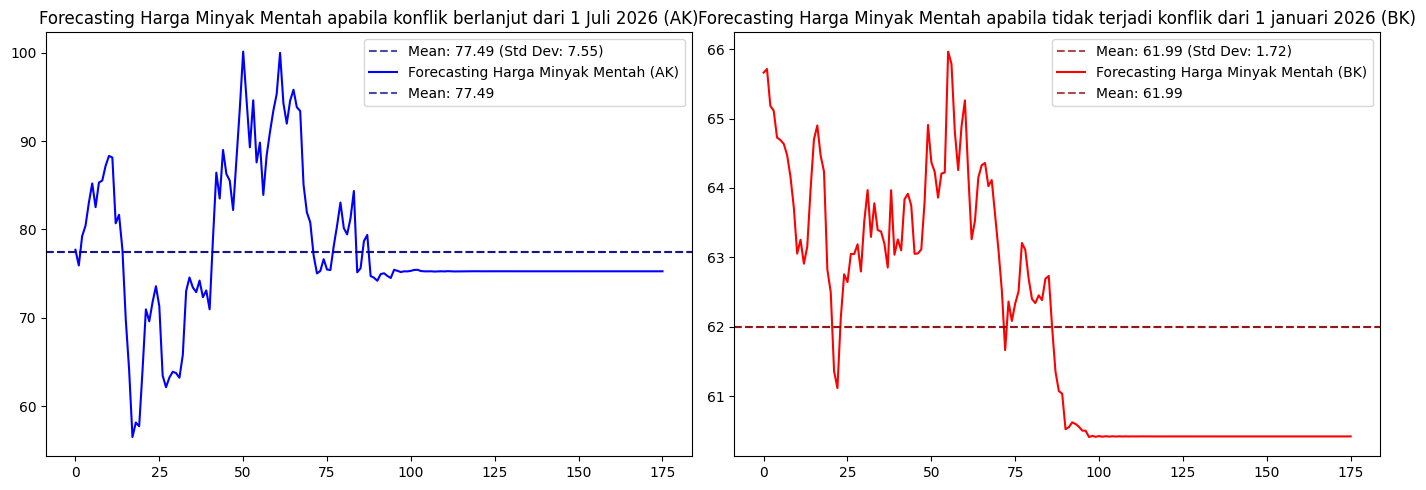

In [198]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik 1: Index Dollar (AK) ---
# 1. Ambil data yang di-plot agar perhitungan rata-ratanya akurat
data_ak = df_1['0'].loc[:175]
mean_ak = data_ak.mean()  # Hitung rata-rata
std_ak = data_ak.std()
axes[0].axhline(mean_ak, color='navy', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_ak:.2f} (Std Dev: {std_ak:.2f})')
axes[0].plot(data_ak, color='blue', label='Forecasting Harga Minyak Mentah (AK)')
# Tambahkan garis rata-rata (gunakan linestyle='--' untuk garis putus-putus)
axes[0].axhline(mean_ak, color='navy', linestyle='--', alpha=0.7, label=f'Mean: {mean_ak:.2f}')
axes[0].set_title('Forecasting Harga Minyak Mentah apabila konflik berlanjut dari 1 Juli 2026 (AK)')
axes[0].legend(loc='best')


# --- Grafik 2: SARIMA (BK) ---
# 2. Ambil data yang di-plot
data_bk = df_2['0'].loc[:175]
mean_bk = data_bk.mean()  # Hitung rata-rata
std_bk = data_bk.std()
axes[1].axhline(mean_bk, color='darkred', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_bk:.2f} (Std Dev: {std_bk:.2f})')
axes[1].plot(data_bk, color='red', label='Forecasting Harga Minyak Mentah (BK)')
# Tambahkan garis rata-rata
axes[1].axhline(mean_bk, color='darkred', linestyle='--', alpha=0.7, label=f'Mean: {mean_bk:.2f}')
axes[1].set_title('Forecasting Harga Minyak Mentah apabila tidak terjadi konflik dari 1 januari 2026 (BK)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

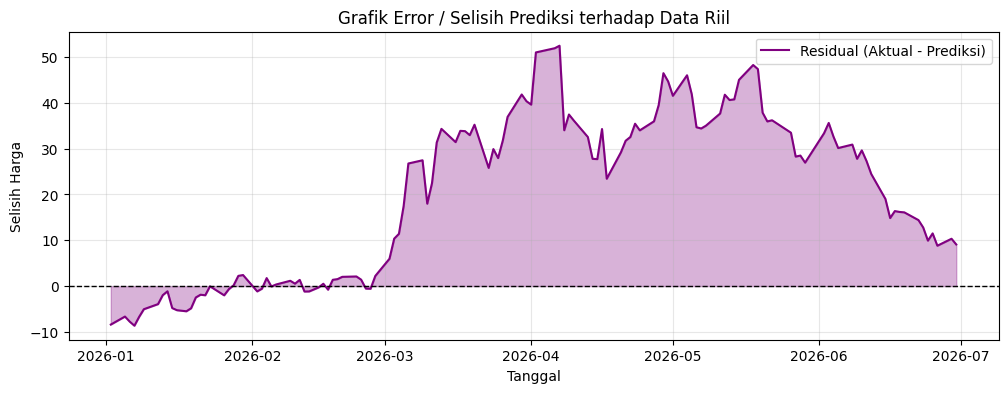

In [199]:
# Hitung selisih (Error/Residual)
aktual = df_minyak_AK.loc[common_index_plot, 'Terakhir']
prediksi = prediksi_BK.loc[common_index_plot]
residual = aktual - prediksi

plt.figure(figsize=(12, 4))
# Plot area untuk memperjelas wilayah positif/negatif
plt.fill_between(common_index_plot, residual, color="purple", alpha=0.3)
plt.plot(common_index_plot, residual, color="purple", label='Residual (Aktual - Prediksi)')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Garis batas nol

plt.title('Grafik Error / Selisih Prediksi terhadap Data Riil')
plt.xlabel('Tanggal')
plt.ylabel('Selisih Harga')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

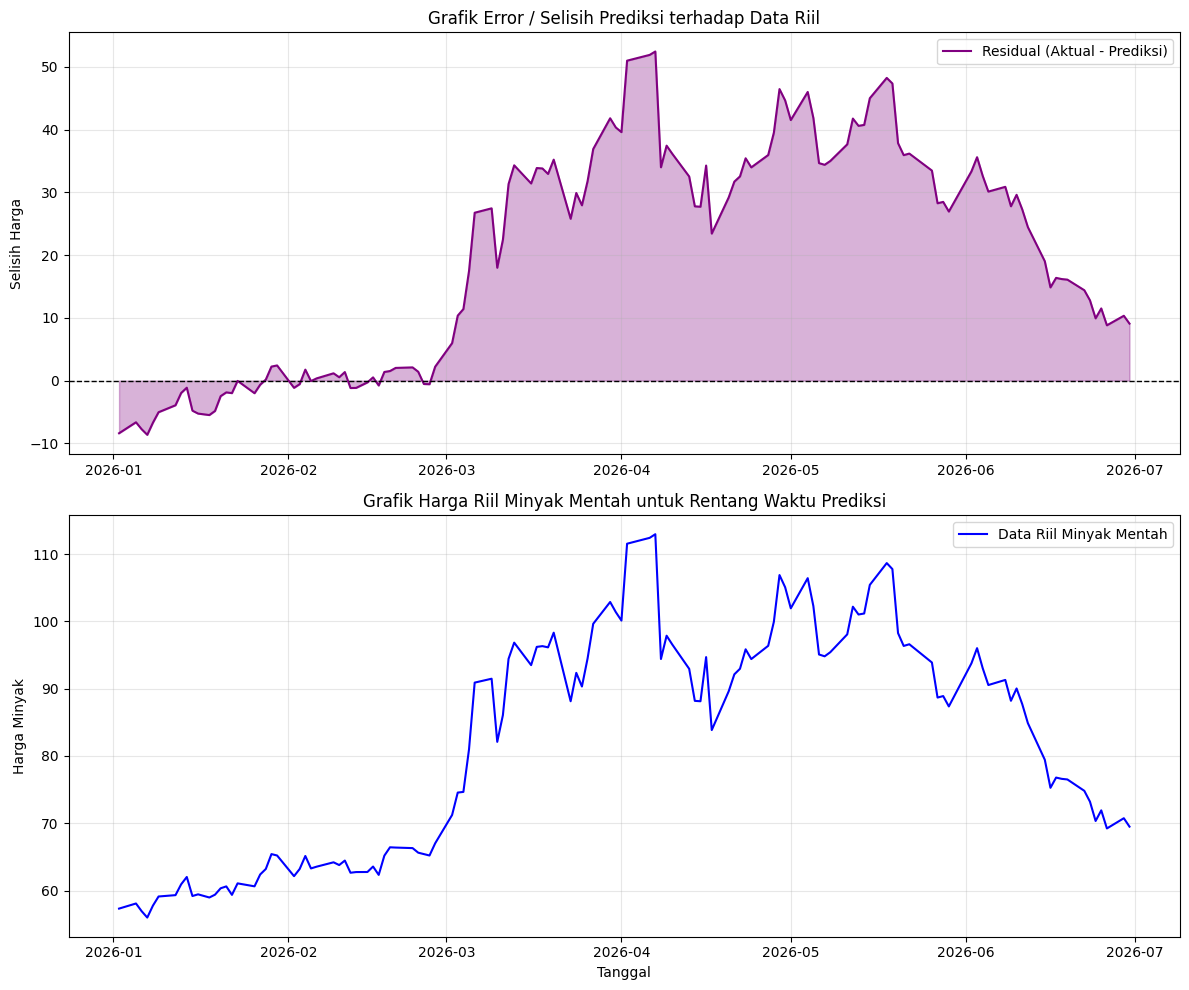

In [200]:
# Gabungkan semua data rill minyak mentah dari BK dan AK
df_minyak_all = pd.concat([df_minyak_BK, df_minyak_AK])

# Ambil rentang tanggal data prediksi yang akan di-plot
tgl_pred = prediksi_BK.loc[common_index_plot].index

# Ambil data riil hanya untuk rentang tanggal tersebut
data_riil_plot = df_minyak_all.loc[tgl_pred, 'Terakhir']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Grafik Atas: Residual ---
axes[0].fill_between(common_index_plot, residual, color="purple", alpha=0.3)
axes[0].plot(common_index_plot, residual, color="purple", label='Residual (Aktual - Prediksi)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Grafik Error / Selisih Prediksi terhadap Data Riil')
axes[0].set_ylabel('Selisih Harga')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# --- Grafik Bawah: Data Riil ---
axes[1].plot(tgl_pred, data_riil_plot, color='blue', label='Data Riil Minyak Mentah')
axes[1].set_title('Grafik Harga Riil Minyak Mentah untuk Rentang Waktu Prediksi')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Harga Minyak')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

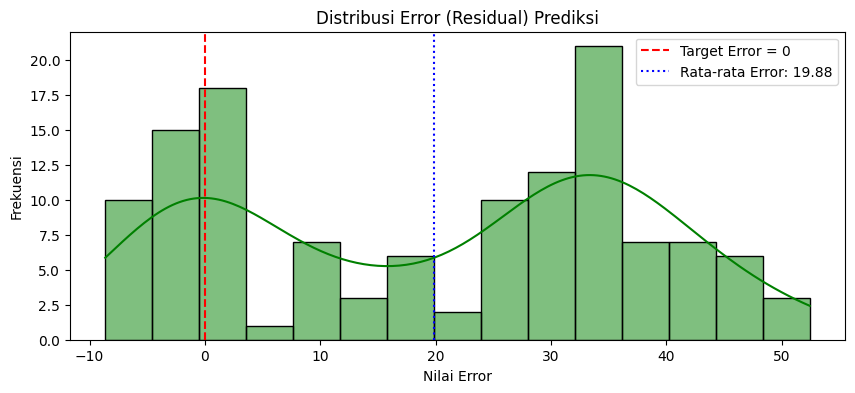

In [201]:
import seaborn as sns # pastikan sudah import seaborn

plt.figure(figsize=(10, 4))
# Plot histogram dan kurva densitas (KDE)
sns.histplot(residual, kde=True, color='green', bins=15)
plt.axvline(0, color='red', linestyle='--', label='Target Error = 0')
plt.axvline(residual.mean(), color='blue', linestyle=':', label=f'Rata-rata Error: {residual.mean():.2f}')

plt.title('Distribusi Error (Residual) Prediksi')
plt.xlabel('Nilai Error')
plt.ylabel('Frekuensi')
plt.legend(loc='best')
plt.show()

df_3 (BK)

In [202]:
import statsmodels.api as sm

  # ganti dengan nilai Index_US yang mau diprediksi

# WAJIB tambah constant juga di data baru, biar bentuknya cocok sama X waktu fit
X_baru_6 = sm.add_constant(df_3['predicted_mean'], has_constant='add')

# Prediksi
prediksi_6 = model_lag_2.predict(X_baru_6)

print(prediksi_6)


0      60.408717
1      60.047253
2      63.753369
3      64.240833
4      66.950862
         ...    
360    97.049455
361    97.049455
362    97.049455
363    97.049455
364    97.049455
Length: 365, dtype: float64


In [203]:
import statsmodels.api as sm

  # ganti dengan nilai Index_US yang mau diprediksi

# WAJIB tambah constant juga di data baru, biar bentuknya cocok sama X waktu fit
X_baru_7 = sm.add_constant(df_3['predicted_mean'], has_constant='add')

# Prediksi
prediksi_7 = model_lag_1.predict(X_baru_7)

print(prediksi_7)


0      65.662033
1      65.713737
2      65.183604
3      65.113876
4      64.726226
         ...    
360    60.420840
361    60.420840
362    60.420840
363    60.420840
364    60.420840
Length: 365, dtype: float64


In [204]:
prediksi_6

,0
0,60.408717
1,60.047253
2,63.753369
3,64.240833
4,66.950862
...,...
360,97.049455
361,97.049455
362,97.049455
363,97.049455


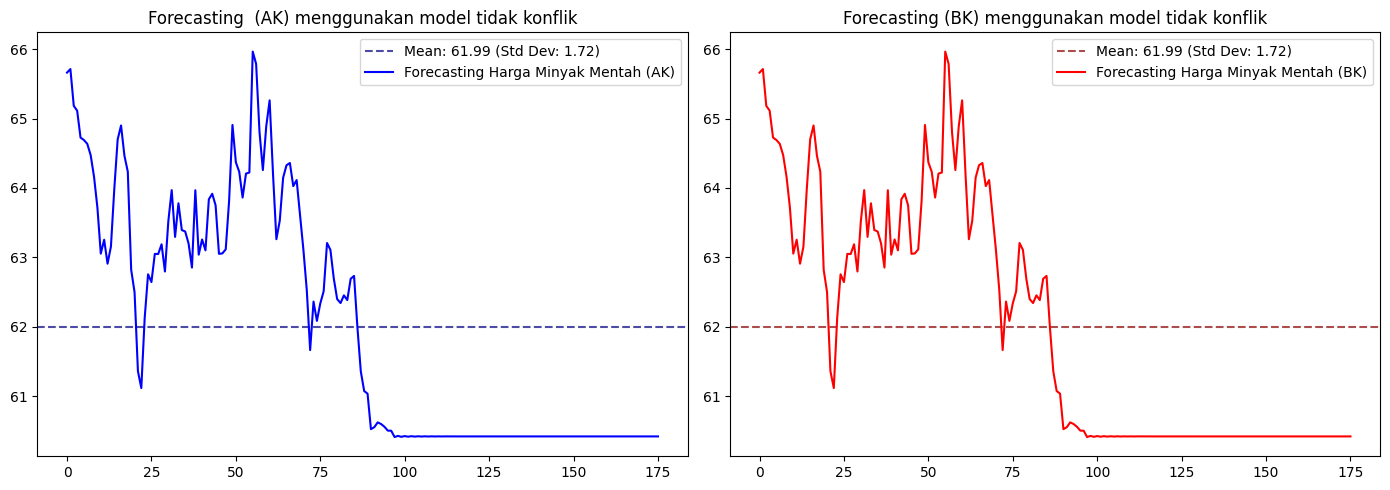

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik 2: SARIMA (BK) ---
data_bk = df_2['0'].loc[:175]
mean_bk = data_bk.mean()
std_bk = data_bk.std()
axes[1].axhline(mean_bk, color='darkred', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_bk:.2f} (Std Dev: {std_bk:.2f})')
axes[1].plot(data_bk, color='red', label='Forecasting Harga Minyak Mentah (BK)')
axes[1].set_title('Forecasting (BK) menggunakan model tidak konflik')
axes[1].legend(loc='best')

# --- Grafik 1: Index Dollar (AK) ---
data_ak = prediksi_7.loc[:175]
mean_ak = data_ak.mean()
std_ak = data_ak.std()
axes[0].axhline(mean_ak, color='navy', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_ak:.2f} (Std Dev: {std_ak:.2f})')
axes[0].plot(data_ak, color='blue', label='Forecasting Harga Minyak Mentah (AK)')
axes[0].set_title('Forecasting  (AK) menggunakan model tidak konflik')
axes[0].legend(loc='best')

plt.tight_layout()
plt.show()

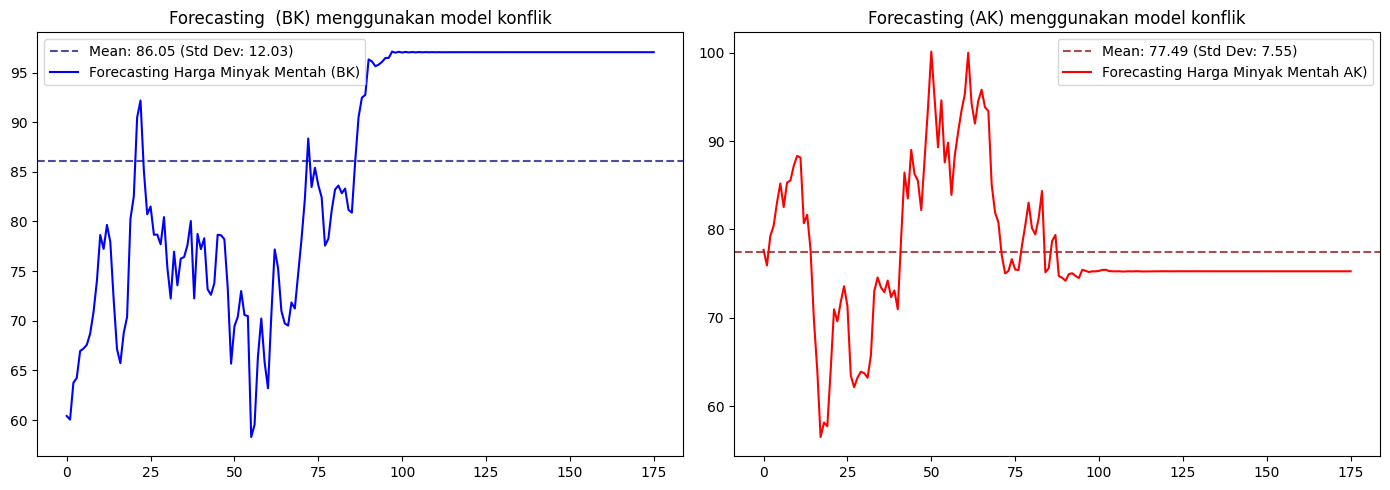

In [206]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik 2: SARIMA (BK) ---
data_bk = df_1['0'].loc[:175]
mean_bk = data_bk.mean()
std_bk = data_bk.std()
axes[1].axhline(mean_bk, color='darkred', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_bk:.2f} (Std Dev: {std_bk:.2f})')
axes[1].plot(data_bk, color='red', label='Forecasting Harga Minyak Mentah AK)')
axes[1].set_title('Forecasting (AK) menggunakan model konflik')
axes[1].legend(loc='best')

# --- Grafik 1: Index Dollar (AK) ---
data_ak = prediksi_6.loc[:175]
mean_ak = data_ak.mean()
std_ak = data_ak.std()
axes[0].axhline(mean_ak, color='navy', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_ak:.2f} (Std Dev: {std_ak:.2f})')
axes[0].plot(data_ak, color='blue', label='Forecasting Harga Minyak Mentah (BK)')
axes[0].set_title('Forecasting  (BK) menggunakan model konflik')
axes[0].legend(loc='best')

plt.tight_layout()
plt.show()

In [207]:
import requests
from getpass import getpass

CREATE_REPO = False  # ganti True kalau mau create repo baru

token = getpass('GitHub token: ')
username = "TiPramudita"
repo_name = "prediksi-sarima-ols-usd-minyak"  # udah valid, tanpa spasi/kurung
headers = {"Authorization": f"token {token}"}

if CREATE_REPO:
    response = requests.post(
        "https://api.github.com/user/repos",
        headers=headers,
        json={"name": repo_name, "private": False}
    )
    print("Status:", response.status_code)
    print("Response:", response.json())

INVITE_COLLABORATORS = False  # ganti True kalau mau invite

collaborators = ["napndini", "cettastami-Ss"]

if INVITE_COLLABORATORS:
    for collab in collaborators:
        r = requests.put(
            f"https://api.github.com/repos/{username}/{repo_name}/collaborators/{collab}",
            headers=headers,
            json={"permission": "push"}
        )
        print(collab, "->", r.status_code)

    

from getpass import getpass
token = getpass('GitHub token: ')

!git clone https://{token}@github.com/TiPramudita/PREDIKSI_SARIMA_OLS-INDEX-US-DOLAR---HARGA-MINYAK-MENTAH-.git
%cd PREDIKSI_SARIMA_OLS-INDEX-US-DOLAR---HARGA-MINYAK-MENTAH-

!git config --global user.email "titipramuditaw235@gmail.com"
!git config --global user.name "TiPramudita"


!git add .
!git commit -m "update pesan commit"
!git push

In [220]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/Colab Notebooks/PREDIKSI SARIMA US INDEX DOLAR dan OLS terhadap HARGA MINYAK MENTAH.ipynb" "/content/PREDIKSI_SARIMA_OLS-INDEX-US-DOLAR---HARGA-MINYAK-MENTAH-/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [221]:
# Pindah ke folder repository
%cd /content/PREDIKSI_SARIMA_OLS-INDEX-US-DOLAR---HARGA-MINYAK-MENTAH-

# Daftarkan file baru/perubahan
!git add .

# Buat commit
!git commit -m "Update notebook dari Google Drive"

# Kirim ke GitHub
!git push origin main

/content/PREDIKSI_SARIMA_OLS-INDEX-US-DOLAR---HARGA-MINYAK-MENTAH-
[main 446fcf9] Update notebook dari Google Drive
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 895 bytes | 895.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/TiPramudita/PREDIKSI_SARIMA_OLS-INDEX-US-DOLAR---HARGA-MINYAK-MENTAH-.git
   dd1a45c..446fcf9  main -> main
